### ANOVA results

Loaded 1353 units from 8 sessions
[20250306, 20250411, 20250417, 20250501, 20250523, 20250602, 20250702, 20250710]

Filtering to 1 selected session(s): [20250411]

SESSION SMALL SHIFTS (Shift amount: ±0.1 mm)
Session 20250411: Original ( 0.00,  1.00) → Shift (  0.00,   0.00) mm (106 units)

Alpha: Responsive = 0.8, Non-responsive = 0.3


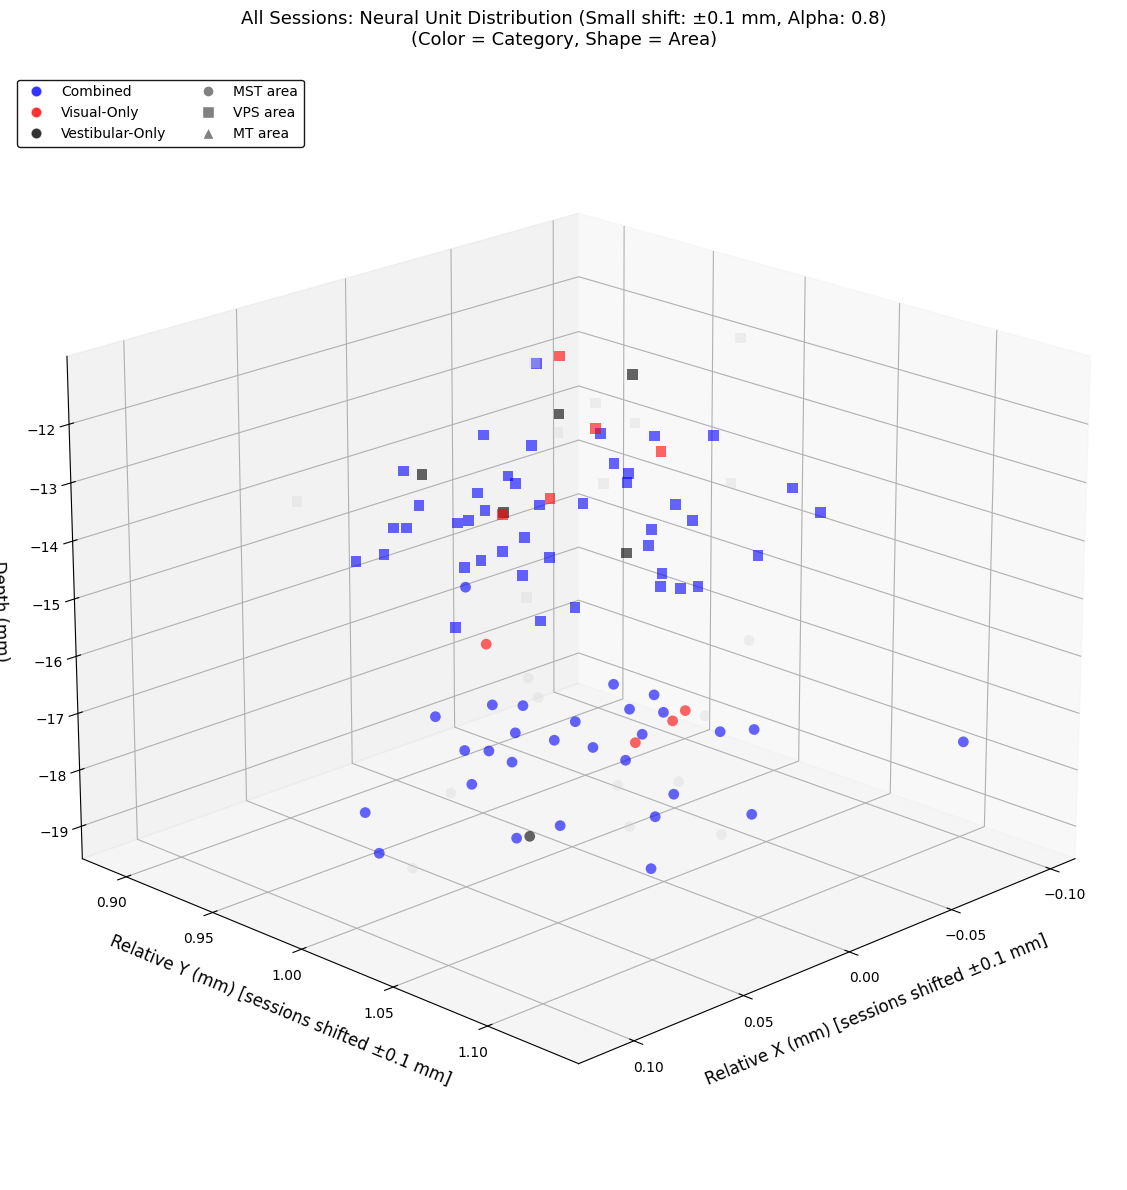

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import ast

# Load data
df = pd.read_csv(r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMPtuning_neuralfeatures\zarya_pooled_neural_features_tuning_stimOn.csv')

print(f"Loaded {len(df)} units from {len(df['date'].unique())} sessions")

# ===== PARSE ARRAYS =====
def safe_eval(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return []
    return x if isinstance(x, list) else []

for modality in ['ves', 'vis', 'comb']:
    df[f'anova_{modality}_p'] = df[f'anova_{modality}_p'].apply(safe_eval)

# ===== DETERMINE SELECTIVITY =====
def is_selective(row, modality, alpha=0.05):
    try:
        p_values = row[f'anova_{modality}_p']
        if not isinstance(p_values, list) or len(p_values) == 0:
            return False
        return any(not np.isnan(p) and p < alpha for p in p_values)
    except:
        return False

df['ves_selective'] = df.apply(lambda row: is_selective(row, 'ves'), axis=1)
df['vis_selective'] = df.apply(lambda row: is_selective(row, 'vis'), axis=1)
df['comb_selective'] = df.apply(lambda row: is_selective(row, 'comb'), axis=1)

def categorize_simple(row):
    if  (row['vis_selective'] and row['ves_selective']) or row['comb_selective']:
        return 'Combined'
    elif row['vis_selective']:
        return 'Visual-Only'
    elif row['ves_selective']:
        return 'Vestibular-Only'
    else:
        return 'Non-responsive'

df['category'] = df.apply(categorize_simple, axis=1)

# ===== MAIN PLOTTING FUNCTION =====
def plot_neural_distribution(df, selected_dates=[]):
    """
    Plot neural unit distribution in 3D space
    
    Parameters:
    -----------
    df : DataFrame
        The neural data
    selected_dates : list
        List of date strings to plot (e.g., ["20250411", "20250306"])
        Leave empty [] to plot all sessions
    """
    
    # ===== SMALL SESSION-SPECIFIC SHIFTS =====
    sessions = sorted(df['date'].unique())
    print(sessions)
    # Filter sessions if specific dates are provided
    if selected_dates:
        sessions = [s for s in sessions if s in selected_dates]
        print(f"\nFiltering to {len(sessions)} selected session(s): {sessions}")
    
    n_sessions = len(sessions)
    
    # CHANGED: Very small shift - just to separate overlapping sessions
    shift_amount = 0.1  # mm (was 1.5)
    
    # Group sessions by their original position and apply small offsets
    session_shifts = {}
    
    for i, session in enumerate(sessions):
        # Get the original position for this session
        session_data = df[df['date'] == session]
        orig_x = session_data['relative_x'].iloc[0]
        orig_y = session_data['relative_y'].iloc[0]
        
        # Apply small alternating shifts: (0.2, 0), (0, 0.2), (-0.2, 0), (0, -0.2), etc.
        shift_patterns = [
            (0, 0),           # No shift
            (shift_amount, 0),     # Right
            (0, shift_amount),     # Up
            (-shift_amount, 0),    # Left
            (0, -shift_amount),    # Down
            (shift_amount, shift_amount),    # Diagonal
            (-shift_amount, shift_amount),   # Diagonal
            (shift_amount, -shift_amount)    # Diagonal
        ]
        
        shift_x, shift_y = shift_patterns[i % len(shift_patterns)]
        session_shifts[session] = (shift_x, shift_y)
    
    print(f"\n{'='*70}")
    print(f"SESSION SMALL SHIFTS (Shift amount: ±{shift_amount} mm)")
    print(f"{'='*70}")
    for session, (shift_x, shift_y) in session_shifts.items():
        n_units = len(df[df['date'] == session])
        session_data = df[df['date'] == session]
        orig_pos = (session_data['relative_x'].iloc[0], session_data['relative_y'].iloc[0])
        print(f"Session {session}: Original ({orig_pos[0]:>5.2f}, {orig_pos[1]:>5.2f}) → Shift ({shift_x:>6.2f}, {shift_y:>6.2f}) mm ({n_units} units)")
    
    # ===== ADD JITTER WITH SMALL SESSION SHIFTS =====
    np.random.seed(42)
    jitter_amount = 0.05
    
    df['jitter_x'] = df['relative_x'] + np.random.normal(0, jitter_amount, len(df))
    df['jitter_y'] = df['relative_y'] + np.random.normal(0, jitter_amount, len(df))
    df['jitter_z'] = -(df['relative_depth'] + np.random.normal(0, jitter_amount, len(df)))
    
    # CHANGED: Apply small session-specific shift
    for session, (shift_x, shift_y) in session_shifts.items():
        mask = df['date'] == session
        df.loc[mask, 'jitter_x'] += shift_x
        df.loc[mask, 'jitter_y'] += shift_y
    
    # ===== TRANSPARENCY =====
    df['alpha'] = 0.6
    df.loc[df['category'] == 'Non-responsive', 'alpha'] = 0.3
    
    print(f"\nAlpha: Responsive = 0.8, Non-responsive = 0.3")
    
    # ===== PLOT =====
    colors = {
        'Combined': 'blue',
        'Visual-Only': 'red',
        'Vestibular-Only': 'black',
        'Non-responsive': 'lightgray'
    }
    
    markers = {
        'MST': 'o',
        'VPS': 's',
        'MT': '^',
        'unknown': 'x'
    }
    
    marker_size = 60
    
    fig = plt.figure(figsize=(16, 12))
    ax = fig.add_subplot(111, projection='3d')
    
    plot_order = ['Non-responsive', 'Vestibular-Only', 'Visual-Only', 'Combined']
    
    for session in sessions:
        session_mask = df['date'] == session
        
        for cat in plot_order:
            for area in df['area'].unique():
                idx = session_mask & (df['category'] == cat) & (df['area'] == area)
                data = df[idx]
                
                if len(data) == 0:
                    continue
                
                alphas = data['alpha'].values
                marker = markers.get(area, 'o')
                
                for i, (x, y, z, alpha_val) in enumerate(zip(data['jitter_x'], data['jitter_y'], 
                                                               data['jitter_z'], alphas)):
                    ax.scatter(x, y, z,
                               c=colors[cat], 
                               marker=marker,
                               s=marker_size,
                               alpha=alpha_val,
                               edgecolors='none', 
                               linewidth=0,
                               label=f'{session}-{cat}-{area}' if i == 0 else '')
    
    # Styling
    ax.set_xlabel(f'Relative X (mm) [sessions shifted ±{shift_amount} mm]', fontsize=12, labelpad=10)
    ax.set_ylabel(f'Relative Y (mm) [sessions shifted ±{shift_amount} mm]', fontsize=12, labelpad=10)
    ax.set_zlabel('Depth (mm)', fontsize=12, labelpad=10)
    ax.set_title(f'All Sessions: Neural Unit Distribution (Small shift: ±{shift_amount} mm, Alpha: 0.8)\n(Color = Category, Shape = Area)', 
                 fontsize=13, pad=20)
    
    # Legend
    from matplotlib.lines import Line2D
    legend_elements = []
    
    for cat, color in colors.items():
        if cat != 'Non-responsive':
            legend_elements.append(Line2D([0], [0], marker='o', color='w', 
                                         markerfacecolor=color, markersize=8, 
                                         label=cat, alpha=0.8))
    
    for area, marker in markers.items():
        if area in df['area'].unique():
            legend_elements.append(Line2D([0], [0], marker=marker, color='w', 
                                         markerfacecolor='gray', markersize=8, 
                                         label=f'{area} area'))
    
    ax.legend(handles=legend_elements, loc='upper left', fontsize=10, 
             framealpha=0.9, edgecolor='black', ncol=2)
    
    ax.grid(True, alpha=0.2, linestyle='--')
    ax.view_init(elev=20, azim=45)
    
    plt.tight_layout()
    plt.show()



# ============================================================================
# ===== RUN THE PLOT - CHANGE DATES HERE =====
# ============================================================================

# To plot specific dates, add them to the list:
plot_neural_distribution(df, selected_dates=[20250411])

# To plot ALL sessions, use an empty list:
# plot_neural_distribution(df, selected_dates=[])

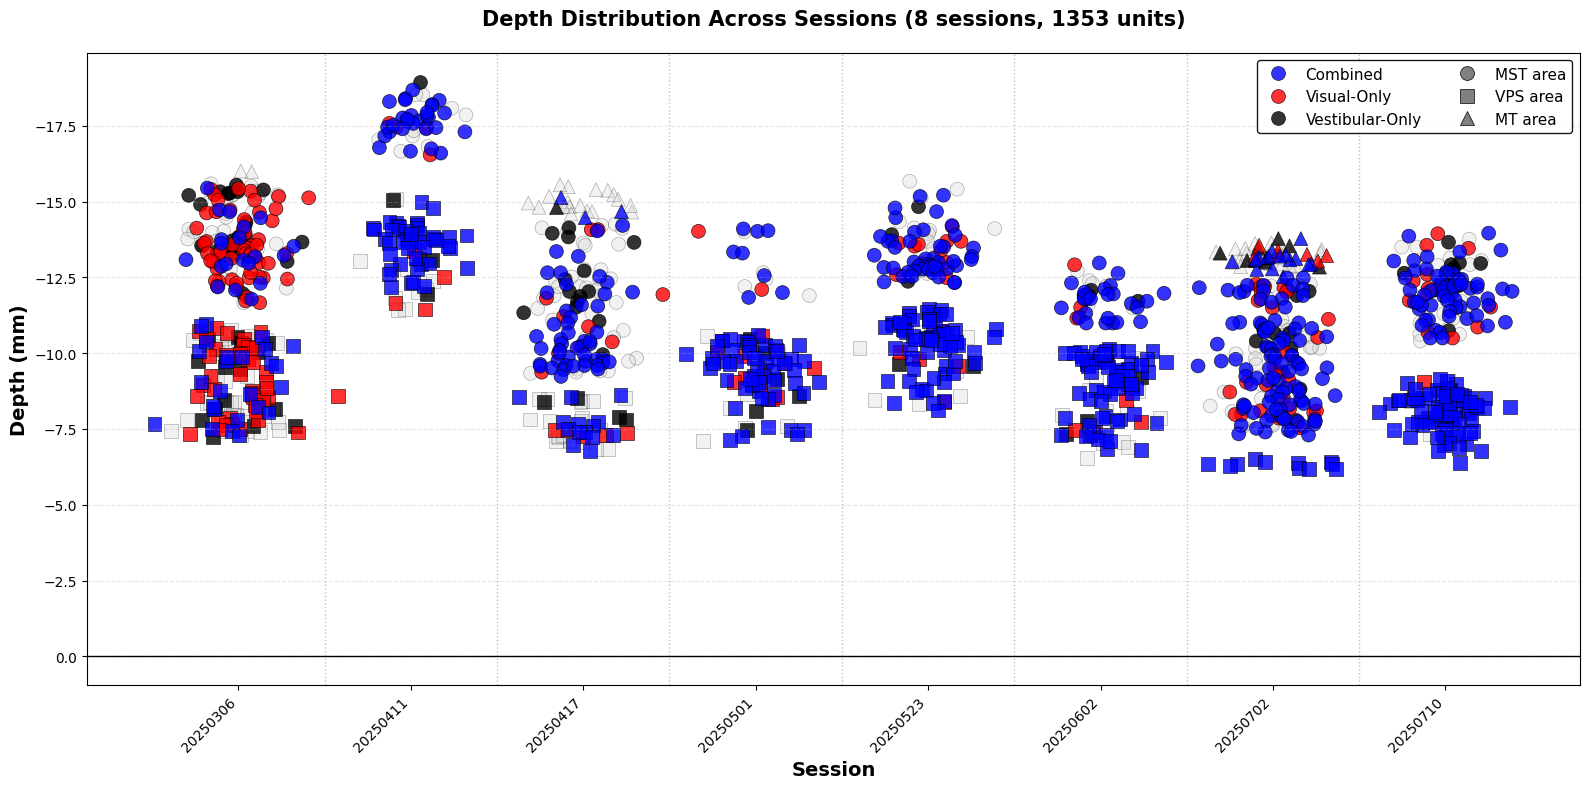


DEPTH STATISTICS BY SESSION

Session 20250306 (Position 1): 275 units
  Depth range: 7.23 to 16.01 mm
  Mean depth: 11.56 ± 2.60 mm
    Combined          :  45 units, depth 11.01 ± 2.37 mm
    Visual-Only       :  98 units, depth 11.62 ± 2.43 mm
    Vestibular-Only   :  41 units, depth 12.10 ± 2.68 mm
    Non-responsive    :  91 units, depth 11.52 ± 2.77 mm

Session 20250411 (Position 2): 106 units
  Depth range: 11.42 to 18.96 mm
  Mean depth: 15.11 ± 2.26 mm
    Combined          :  72 units, depth 15.22 ± 2.09 mm
    Visual-Only       :   9 units, depth 14.64 ± 2.45 mm
    Vestibular-Only   :   6 units, depth 14.32 ± 2.28 mm
    Non-responsive    :  19 units, depth 15.14 ± 2.69 mm

Session 20250417 (Position 3): 176 units
  Depth range: 6.77 to 15.55 mm
  Mean depth: 10.89 ± 2.51 mm
    Combined          :  66 units, depth 10.31 ± 1.97 mm
    Visual-Only       :  15 units, depth 10.06 ± 2.27 mm
    Vestibular-Only   :  19 units, depth 11.56 ± 2.11 mm
    Non-responsive    :  76 uni

In [118]:
# ============================================================================
# ===== 2D DEPTH DISTRIBUTION - SESSIONS SIDE BY SIDE =====
# ============================================================================

def plot_depth_by_session(df, selected_dates=[]):
    """
    Plot depth distribution with each session at a different X position
    
    Parameters:
    -----------
    df : DataFrame
        The neural data
    selected_dates : list
        List of date strings to plot (e.g., ["20250411", "20250306"])
        Leave empty [] to plot all sessions
    """
    
    # Filter sessions if specific dates are provided
    sessions = sorted(df['date'].unique())
    if selected_dates:
        sessions = [s for s in sessions if s in selected_dates]
        print(f"\nPlotting {len(sessions)} selected session(s): {sessions}")
    
    # Filter data to selected sessions
    if selected_dates:
        plot_df = df[df['date'].isin(sessions)].copy()
    else:
        plot_df = df.copy()
    
    # Colors and markers
    colors = {
        'Combined': 'blue',
        'Visual-Only': 'red',
        'Vestibular-Only': 'black',
        'Non-responsive': 'lightgray'
    }
    
    markers = {
        'MST': 'o',
        'VPS': 's',
        'MT': '^',
        'unknown': 'x'
    }
    
    marker_size = 100
    
    # Set transparency
    plot_df['alpha'] = 0.8
    plot_df.loc[plot_df['category'] == 'Non-responsive', 'alpha'] = 0.3
    
    # Create figure
    fig, ax = plt.subplots(figsize=(max(12, len(sessions) * 2), 8))
    
    plot_order = ['Non-responsive', 'Vestibular-Only', 'Visual-Only', 'Combined']
    
    # Assign each session a position on X axis
    session_positions = {session: i + 1 for i, session in enumerate(sessions)}
    
    # Add small jitter to avoid overlapping points
    np.random.seed(42)
    jitter_amount = 0.15
    
    # Plot each session
    for session in sessions:
        x_pos = session_positions[session]
        session_data = plot_df[plot_df['date'] == session]
        
        for cat in plot_order:
            for area in session_data['area'].unique():
                data = session_data[(session_data['category'] == cat) & (session_data['area'] == area)]
                if len(data) == 0:
                    continue
                
                marker = markers.get(area, 'o')
                alphas = data['alpha'].values
                
                # Add small jitter to X position
                x_positions = np.ones(len(data)) * x_pos + np.random.normal(0, jitter_amount, len(data))
                depths = -data['relative_depth'].values  # Negative for plotting (depth increases downward)
                
                ax.scatter(x_positions, depths,
                          c=colors[cat], marker=marker, s=marker_size,
                          alpha=alphas, edgecolors='black', linewidth=0.5,
                          label=f'{cat}-{area}' if session == sessions[0] else '')
    
    # Styling
    ax.set_xlabel('Session', fontsize=14, fontweight='bold')
    ax.set_ylabel('Depth (mm)', fontsize=14, fontweight='bold')
    ax.set_title(f'Depth Distribution Across Sessions ({len(sessions)} sessions, {len(plot_df)} units)', 
                 fontsize=15, fontweight='bold', pad=20)
    
    # Set X ticks to session names
    ax.set_xticks(list(session_positions.values()))
    ax.set_xticklabels(list(session_positions.keys()), rotation=45, ha='right')
    
    # Grid
    ax.grid(True, alpha=0.3, linestyle='--', axis='y')
    ax.axhline(y=0, color='k', linestyle='-', linewidth=1)
    
    # Add vertical lines to separate sessions
    for i in range(1, len(sessions)):
        ax.axvline(x=i + 0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    
    # Invert Y axis so depth increases downward
    ax.invert_yaxis()
    
    # Create legend
    from matplotlib.lines import Line2D
    legend_elements = []
    
    # Category colors
    for cat, color in colors.items():
        if cat != 'Non-responsive':
            legend_elements.append(Line2D([0], [0], marker='o', color='w', 
                                         markerfacecolor=color, markersize=10, 
                                         label=cat, alpha=0.8, 
                                         markeredgecolor='black', markeredgewidth=0.5))
    
    # Area markers
    for area, marker in markers.items():
        if area in plot_df['area'].unique():
            legend_elements.append(Line2D([0], [0], marker=marker, color='w', 
                                         markerfacecolor='gray', markersize=10, 
                                         label=f'{area} area',
                                         markeredgecolor='black', markeredgewidth=0.5))
    
    ax.legend(handles=legend_elements, loc='best', fontsize=11, 
             framealpha=0.9, edgecolor='black', ncol=2)
    
    plt.tight_layout()
    plt.show()
    
    # Print depth statistics by session
    print(f"\n{'='*70}")
    print("DEPTH STATISTICS BY SESSION")
    print(f"{'='*70}")
    
    for session in sessions:
        session_data = plot_df[plot_df['date'] == session]
        if len(session_data) == 0:
            continue
        
        depths = session_data['relative_depth'].values
        print(f"\nSession {session} (Position {session_positions[session]}): {len(session_data)} units")
        print(f"  Depth range: {depths.min():.2f} to {depths.max():.2f} mm")
        print(f"  Mean depth: {depths.mean():.2f} ± {depths.std():.2f} mm")
        
        for cat in ['Combined', 'Visual-Only', 'Vestibular-Only', 'Non-responsive']:
            cat_data = session_data[session_data['category'] == cat]
            if len(cat_data) > 0:
                cat_depths = cat_data['relative_depth'].values
                print(f"    {cat:<18}: {len(cat_data):>3} units, depth {cat_depths.mean():.2f} ± {cat_depths.std():.2f} mm")


# ============================================================================
# ===== RUN THE DEPTH PLOT - CHANGE DATES HERE =====
# ============================================================================

# Plot specific dates:
# plot_depth_by_session(df, selected_dates=["20250411", "20250306"])

# Or plot all sessions:
plot_depth_by_session(df, selected_dates=[])

### Neurometric quality check


ANALYZING TUNING DATA BY BRAIN AREA - ALL UNITS
File: D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMPtuning_neuralfeatures\zarya_pooled_neural_features_tuning_stimOn.csv

Preparing data (extracting best thresholds from lists)...

After preparation:
  Available threshold columns: ['vis_neurometric_threshold', 'ves_neurometric_threshold', 'comb_neurometric_threshold']
  Available R² columns: ['vis_neurometric_r2', 'ves_neurometric_r2', 'comb_neurometric_r2']

Brain areas found: ['MST' 'VPS' 'MT']

Quality Check:
  VIS: 1343/1353 units with valid thresholds (99.3%)
  VES: 1341/1353 units with valid thresholds (99.1%)
  COMB: 1342/1353 units with valid thresholds (99.2%)

----------------------------------------
AREA: MST
----------------------------------------
Total units in MST: 706


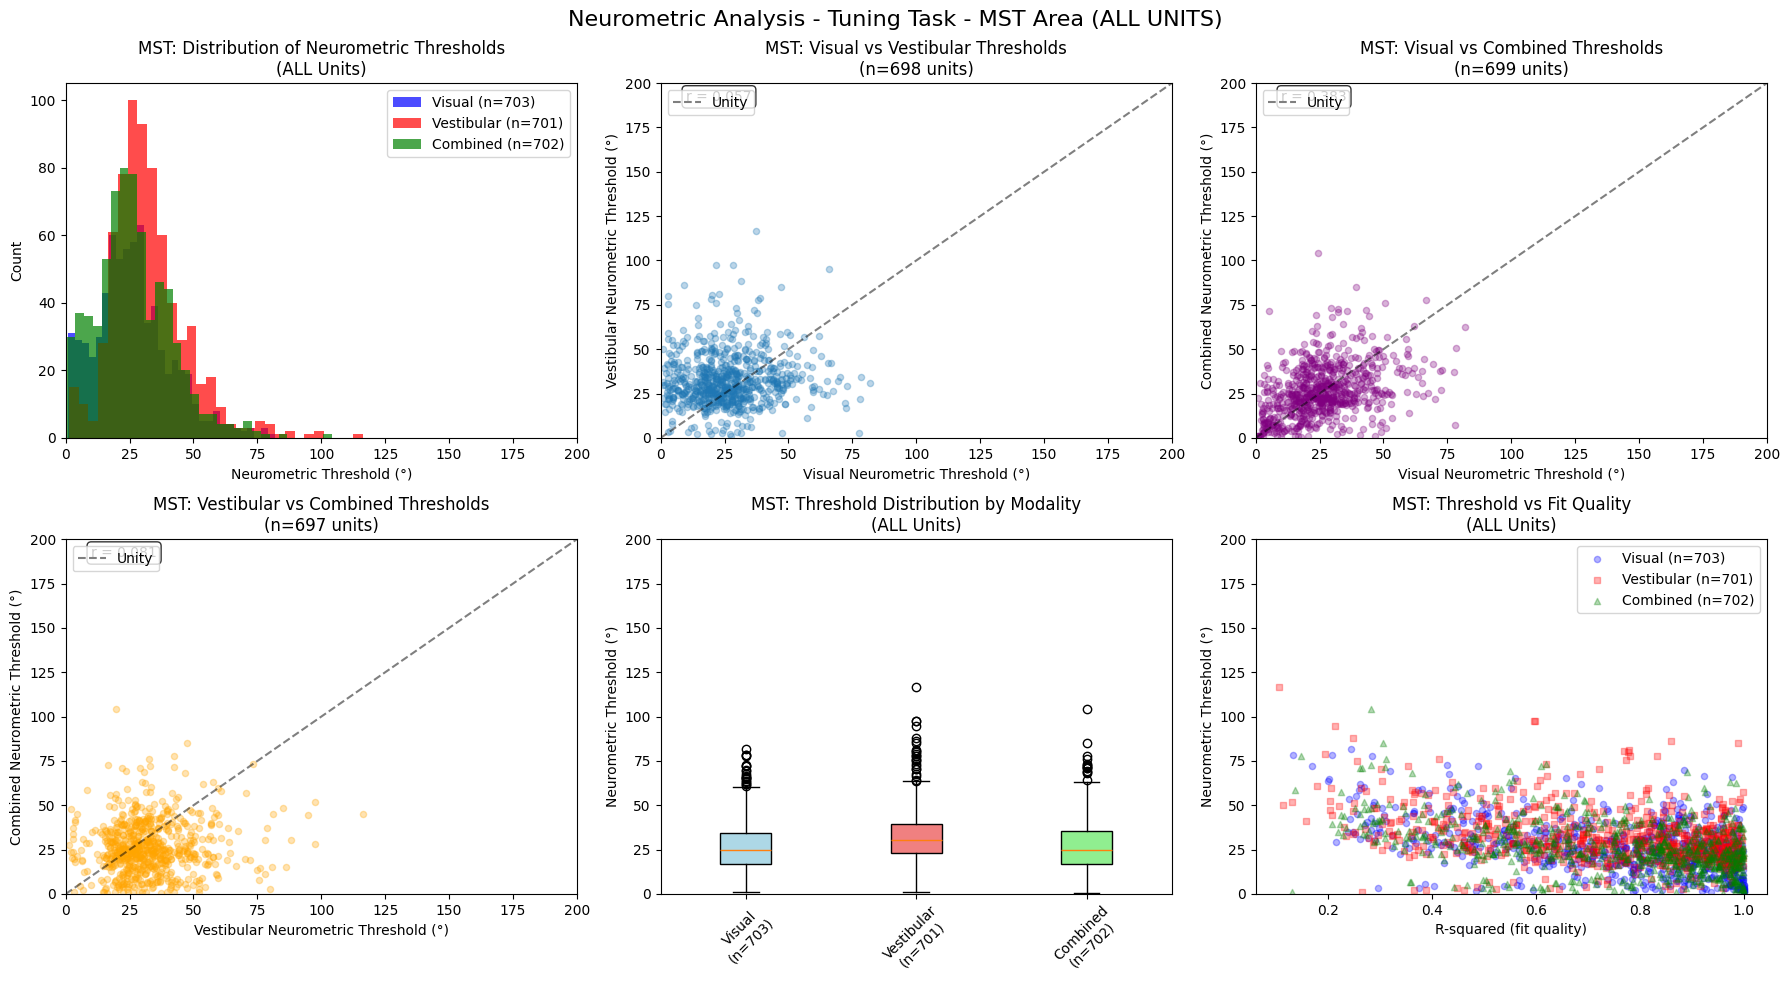


Summary Statistics for MST (Tuning Task - ALL UNITS):

Visual: 703 units with valid thresholds
  Mean: 26.47°
  Median: 25.06°
  Range: 0.89° - 81.93°
  Mean R²: 0.757

Vestibular: 701 units with valid thresholds
  Mean: 32.62°
  Median: 30.25°
  Range: 1.19° - 116.43°
  Mean R²: 0.720

Combined: 702 units with valid thresholds
  Mean: 26.47°
  Median: 24.76°
  Range: 0.35° - 104.07°
  Mean R²: 0.745

----------------------------------------
AREA: VPS
----------------------------------------
Total units in VPS: 568


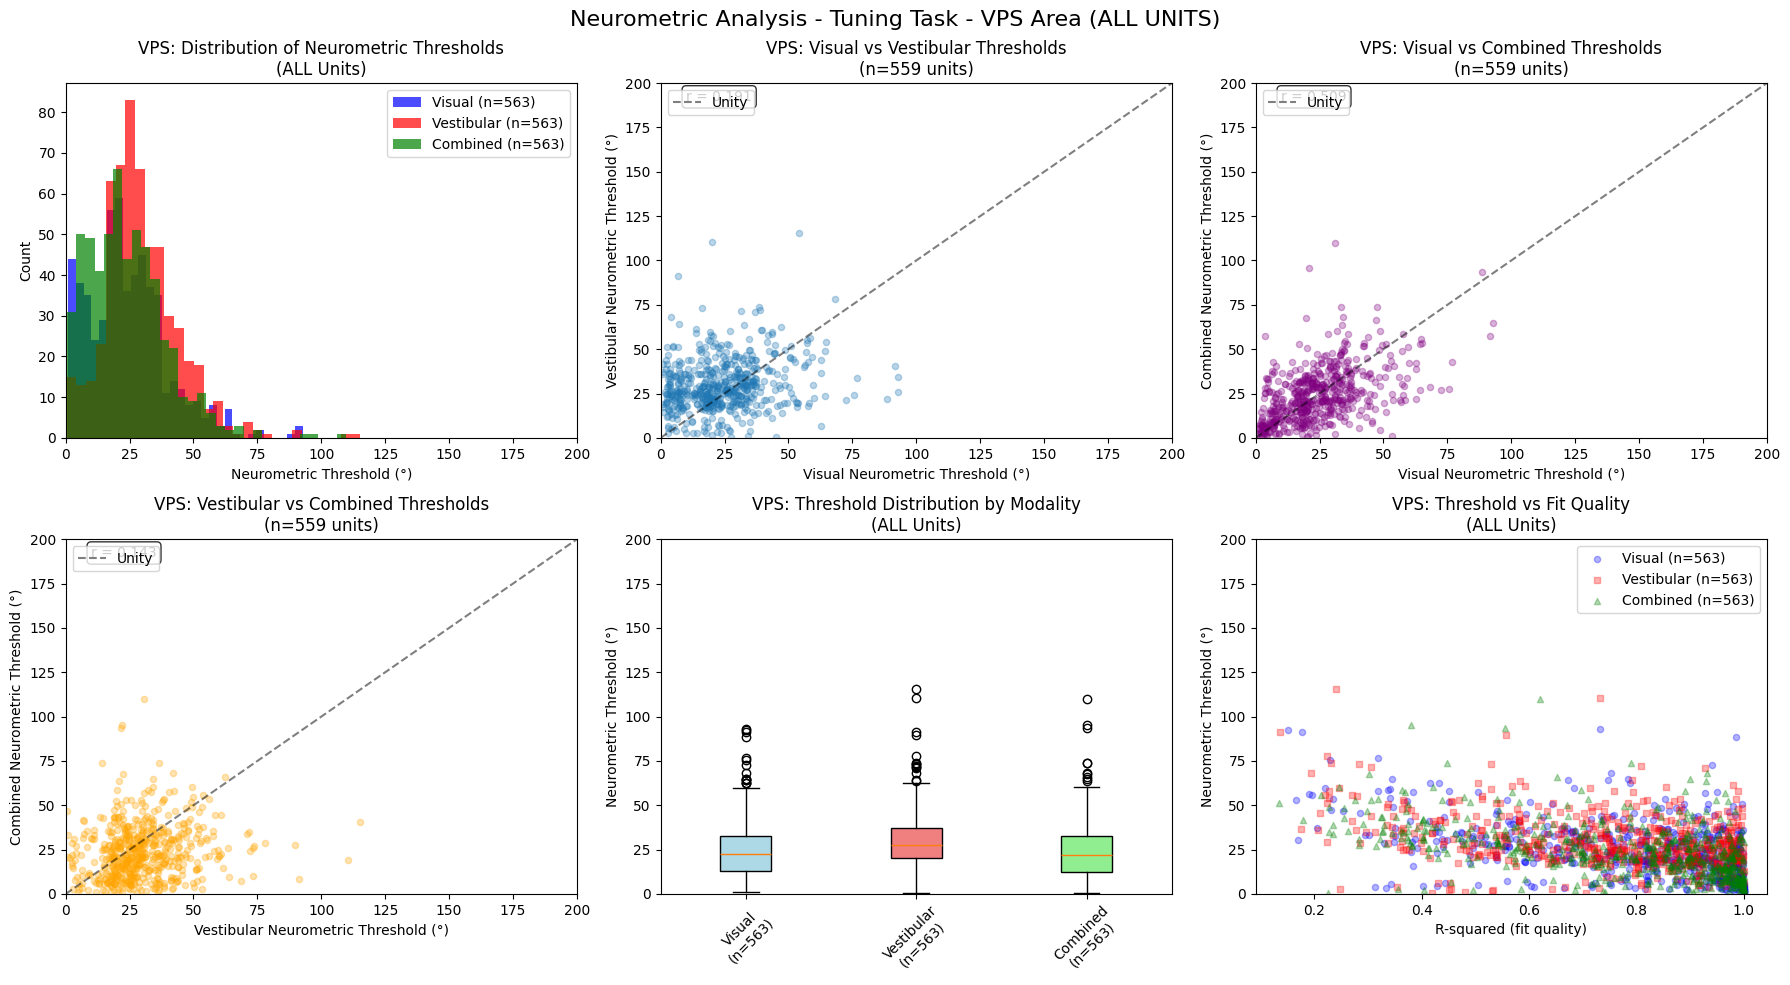


Summary Statistics for VPS (Tuning Task - ALL UNITS):

Visual: 563 units with valid thresholds
  Mean: 24.43°
  Median: 22.29°
  Range: 0.90° - 92.86°
  Mean R²: 0.793

Vestibular: 563 units with valid thresholds
  Mean: 29.93°
  Median: 27.50°
  Range: 0.35° - 115.31°
  Mean R²: 0.738

Combined: 563 units with valid thresholds
  Mean: 24.08°
  Median: 21.78°
  Range: 0.35° - 109.72°
  Mean R²: 0.772

----------------------------------------
AREA: MT
----------------------------------------
Total units in MT: 79


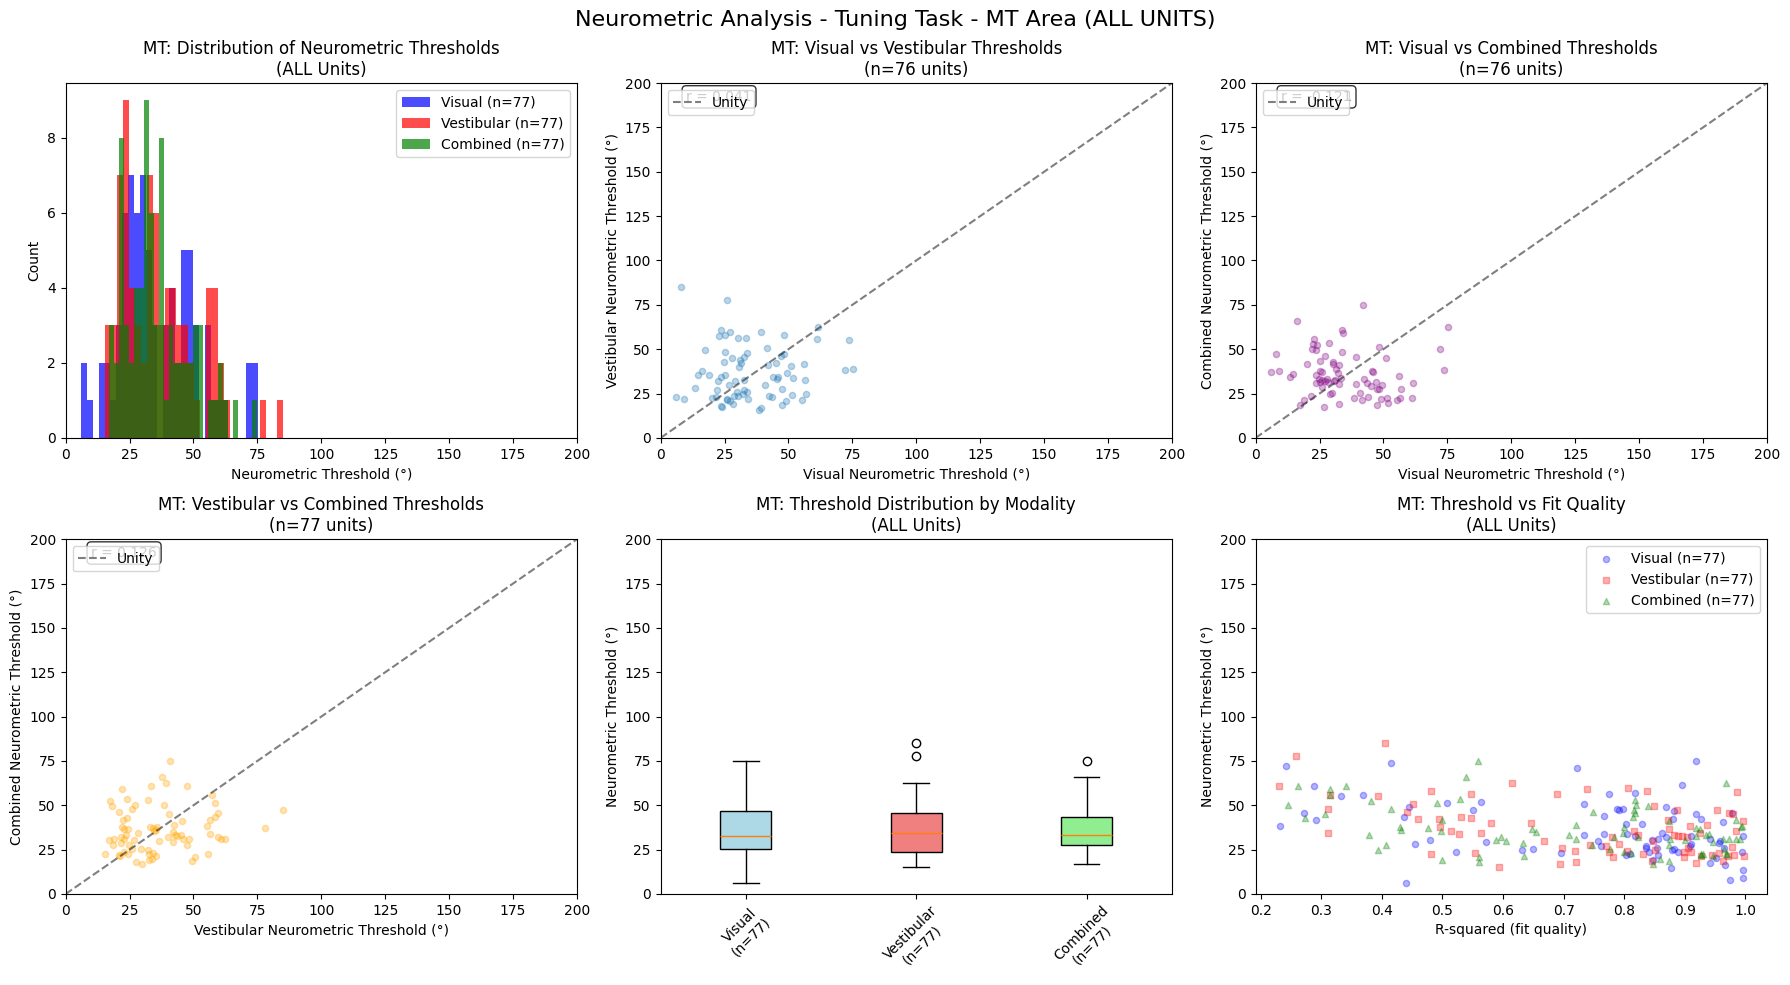


Summary Statistics for MT (Tuning Task - ALL UNITS):

Visual: 77 units with valid thresholds
  Mean: 35.95°
  Median: 32.53°
  Range: 5.94° - 75.11°
  Mean R²: 0.755

Vestibular: 77 units with valid thresholds
  Mean: 36.64°
  Median: 34.13°
  Range: 15.43° - 85.19°
  Mean R²: 0.737

Combined: 77 units with valid thresholds
  Mean: 36.25°
  Median: 33.33°
  Range: 17.13° - 74.95°
  Mean R²: 0.712

ANALYZING REGULAR DATA BY BRAIN AREA - ALL UNITS
File: D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMP_neuralfeatures\zarya_pooled_neural_features_regular_saccOnset.csv

Preparing data (extracting best thresholds from lists)...


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



After preparation:
  Available threshold columns: ['vis_neurometric_threshold', 'ves_neurometric_threshold', 'comb_neurometric_threshold']
  Available R² columns: ['vis_neurometric_r2', 'ves_neurometric_r2', 'comb_neurometric_r2']

Brain areas found: ['MST' 'VPS' 'MT']

Quality Check:
  VIS: 0/1353 units with valid thresholds (0.0%)
  VES: 0/1353 units with valid thresholds (0.0%)
  COMB: 0/1353 units with valid thresholds (0.0%)

----------------------------------------
AREA: MST
----------------------------------------
Total units in MST: 706


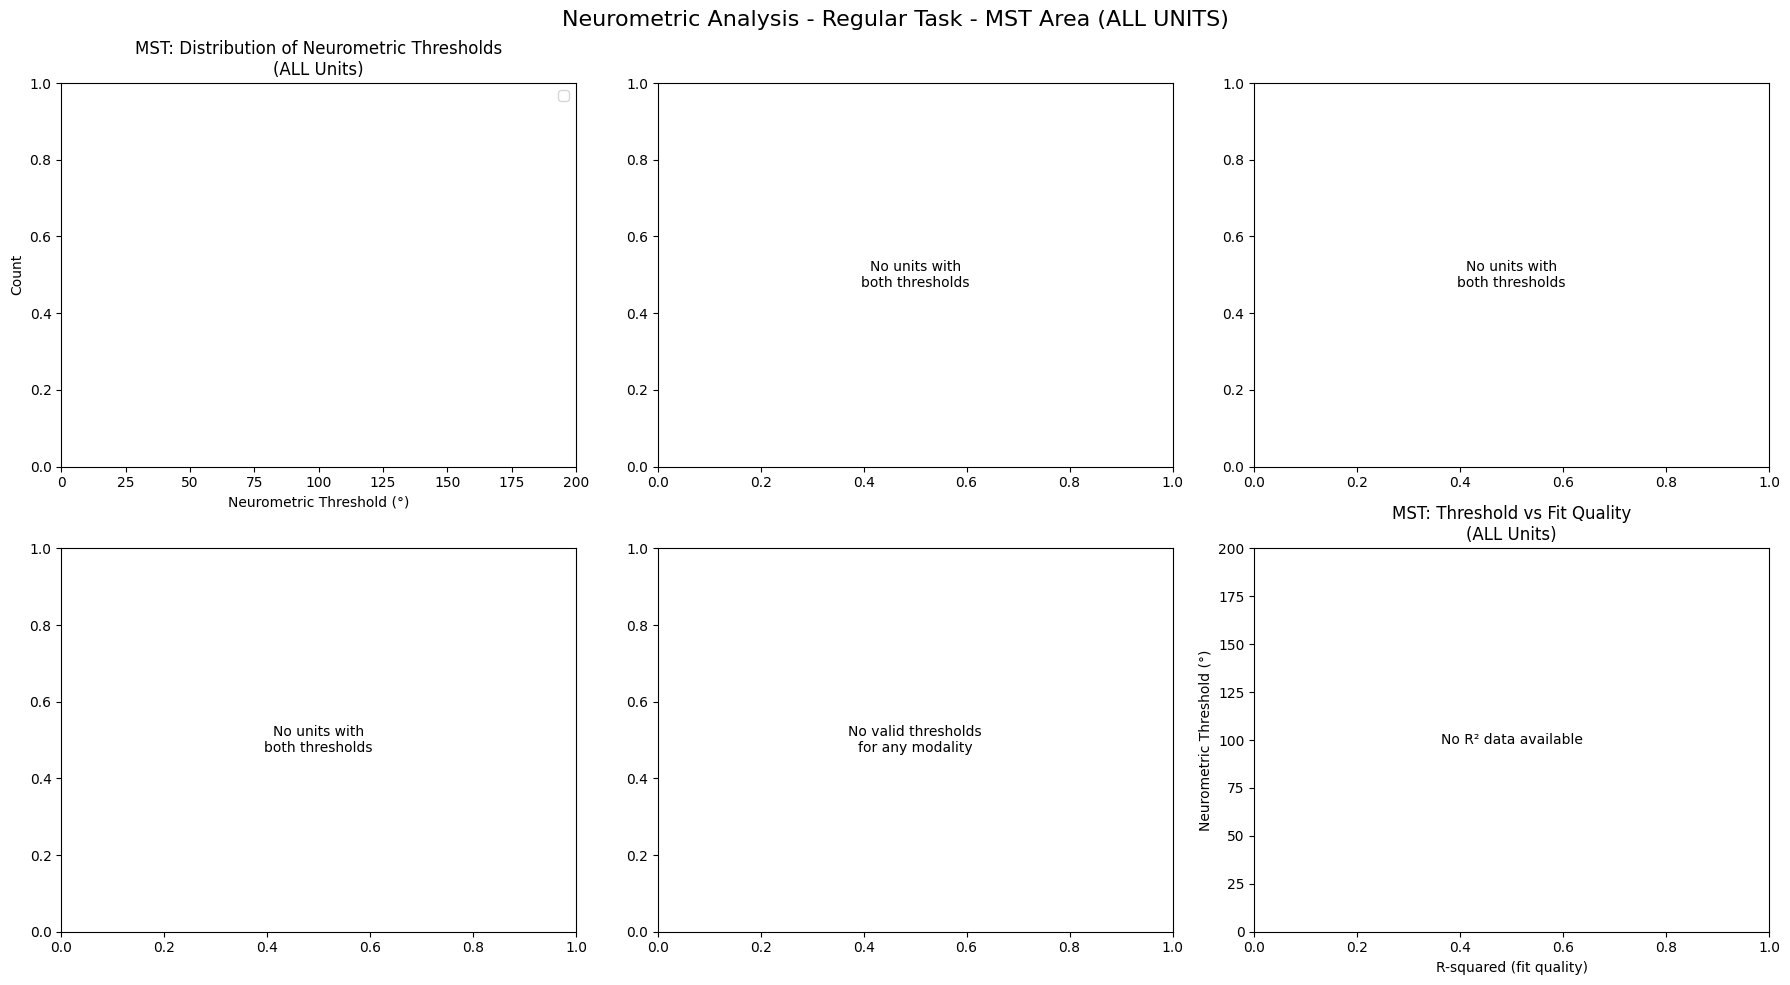

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



Summary Statistics for MST (Regular Task - ALL UNITS):

Visual: 0 units with valid thresholds

Vestibular: 0 units with valid thresholds

Combined: 0 units with valid thresholds

----------------------------------------
AREA: VPS
----------------------------------------
Total units in VPS: 568


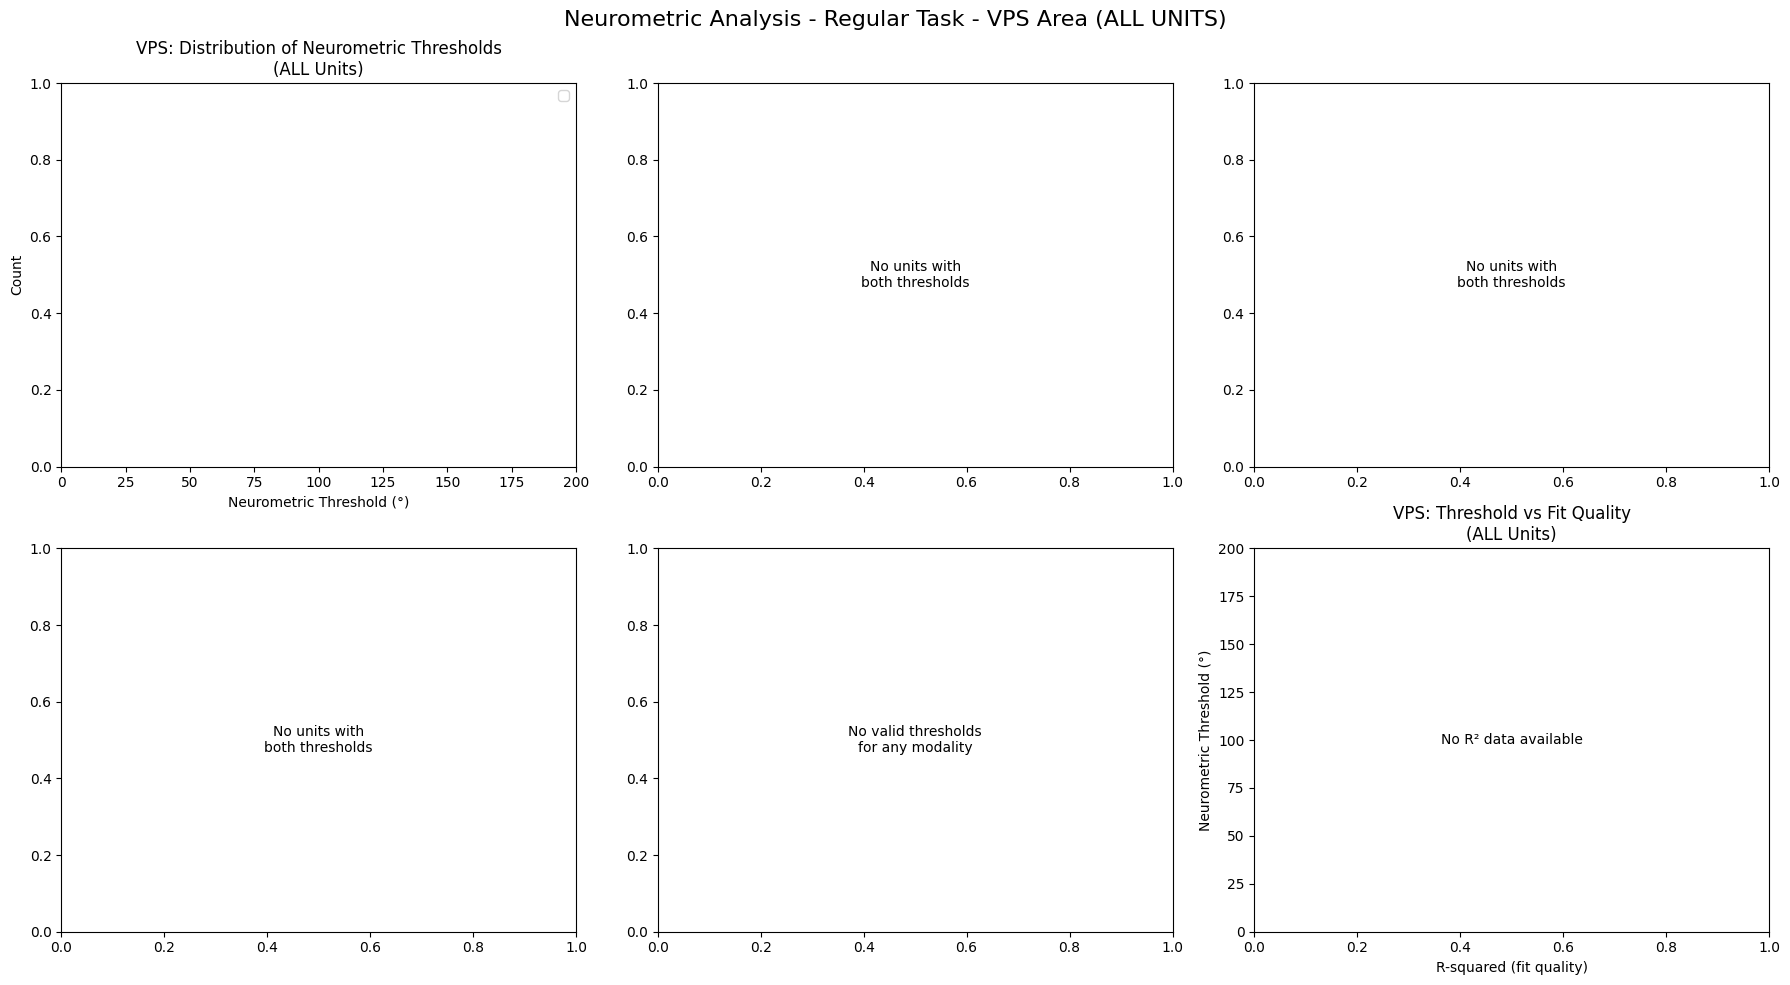

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



Summary Statistics for VPS (Regular Task - ALL UNITS):

Visual: 0 units with valid thresholds

Vestibular: 0 units with valid thresholds

Combined: 0 units with valid thresholds

----------------------------------------
AREA: MT
----------------------------------------
Total units in MT: 79


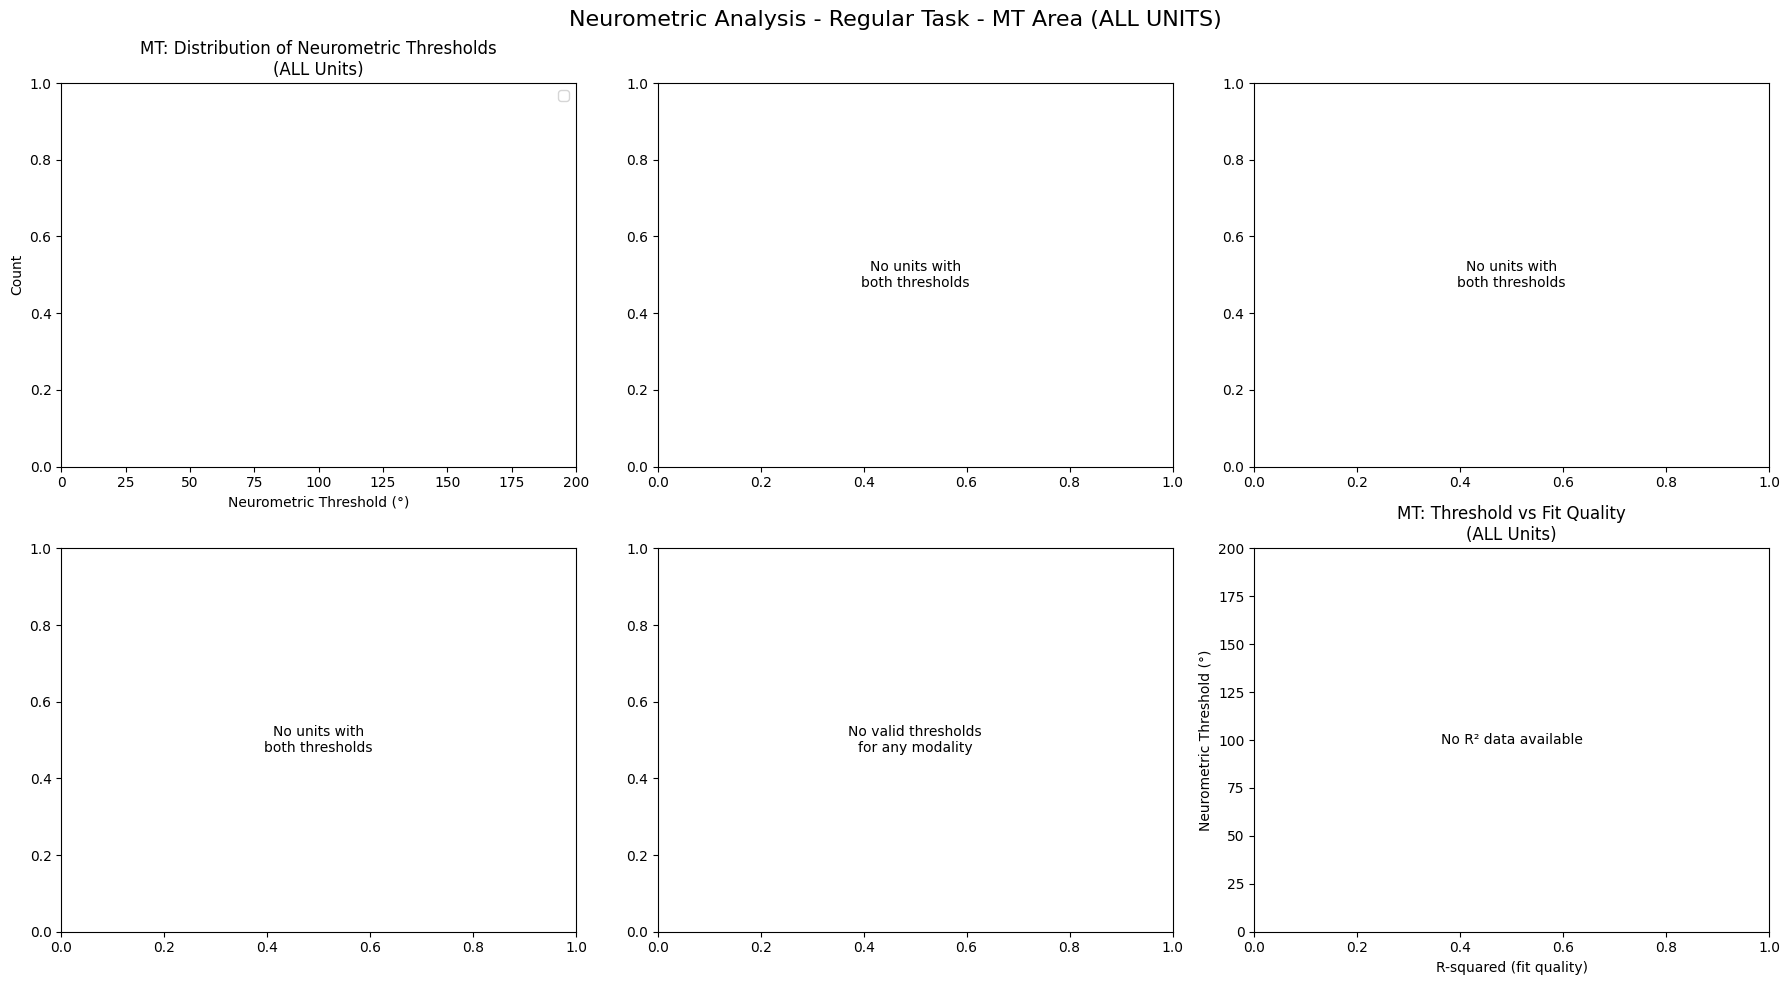


Summary Statistics for MT (Regular Task - ALL UNITS):

Visual: 0 units with valid thresholds

Vestibular: 0 units with valid thresholds

Combined: 0 units with valid thresholds


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast

def parse_list_column(value):
    """
    Parse list-like strings or actual lists into numpy arrays
    Handles both string representations and actual lists
    """
    if pd.isna(value):
        return np.array([])
    
    if isinstance(value, str):
        try:
            # Try to parse as literal list
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return np.array([x for x in parsed if not (isinstance(x, float) and np.isnan(x))])
            else:
                return np.array([parsed]) if not np.isnan(parsed) else np.array([])
        except:
            return np.array([])
    elif isinstance(value, (list, np.ndarray)):
        return np.array([x for x in value if not (isinstance(x, float) and np.isnan(x))])
    elif isinstance(value, (int, float)):
        return np.array([value]) if not np.isnan(value) else np.array([])
    else:
        return np.array([])

def extract_best_threshold(row, modality, threshold_col, r2_col, best_center_col):
    """
    Extract the best threshold for a modality based on best_center_ms
    Works with new format that stores lists
    """
    # Get best center time
    best_center = row.get(best_center_col, None)
    if pd.isna(best_center):
        return np.nan, np.nan
    
    # Get threshold and r2 lists
    thresholds = parse_list_column(row.get(threshold_col, []))
    r2s = parse_list_column(row.get(r2_col, []))
    centers = parse_list_column(row.get(f'neurometric_{modality}_centers', []))
    
    if len(thresholds) == 0 or len(centers) == 0:
        return np.nan, np.nan
    
    # Find index of best center
    try:
        best_idx = np.where(np.abs(centers - best_center) < 1)[0]
        if len(best_idx) > 0:
            best_idx = best_idx[0]
            threshold = thresholds[best_idx] if best_idx < len(thresholds) else np.nan
            r2 = r2s[best_idx] if best_idx < len(r2s) else np.nan
            return threshold, r2
    except:
        pass
    
    # Fallback: use first valid value
    threshold = thresholds[0] if len(thresholds) > 0 else np.nan
    r2 = r2s[0] if len(r2s) > 0 else np.nan
    return threshold, r2

def prepare_dataframe_for_analysis(df, task_type="tuning"):
    """
    Prepare dataframe by extracting best thresholds from list format
    Creates columns compatible with the old format
    """
    df_prepared = df.copy()
    
    # Define modalities to process
    modalities = ['ves', 'vis', 'comb']
    
    for modality in modalities:
        threshold_col = f'neurometric_{modality}_thresholds'
        r2_col = f'neurometric_{modality}_r2'
        best_center_col = f'neurometric_{modality}_best_center_ms'
        
        # Check if columns exist
        if threshold_col not in df.columns:
            continue
        
        # Extract best thresholds and r2 values
        best_thresholds = []
        best_r2s = []
        
        for idx, row in df.iterrows():
            threshold, r2 = extract_best_threshold(row, modality, threshold_col, r2_col, best_center_col)
            best_thresholds.append(threshold)
            best_r2s.append(r2)
        
        # Add as new columns (compatible with old format)
        df_prepared[f'{modality}_neurometric_threshold'] = best_thresholds
        df_prepared[f'{modality}_neurometric_r2'] = best_r2s
    
    # Handle selective columns (these might be in different formats)
    for modality in modalities:
        # Check for ANOVA p-values
        pval_col = f'anova_{modality}_p'
        if pval_col in df.columns:
            # Parse if it's a list
            pvals = []
            for val in df[pval_col]:
                parsed = parse_list_column(val)
                pval = parsed[0] if len(parsed) > 0 else np.nan
                pvals.append(pval)
            df_prepared[f'{modality}_pval'] = pvals
            df_prepared[f'{modality}_selective'] = (np.array(pvals) < 0.05).astype(int)
        elif f'{modality}_pval' in df.columns:
            # Already in correct format
            df_prepared[f'{modality}_selective'] = (df[f'{modality}_pval'] < 0.05).astype(int)
    
    return df_prepared

def analyze_neurometric_data_by_area_all_units(file_path, task_type="tuning"):
    """
    Analyze neurometric data for ALL units (not just selective ones)
    
    Parameters:
    -----------
    file_path : str
        Path to the CSV file
    task_type : str
        "tuning" or "regular" to adjust analysis accordingly
    """
    
    # Load the data
    df_raw = pd.read_csv(file_path)
    
    print(f"\n{'='*60}")
    print(f"ANALYZING {task_type.upper()} DATA BY BRAIN AREA - ALL UNITS")
    print(f"{'='*60}")
    print(f"File: {file_path}")
    
    # Prepare dataframe (extract best values from lists)
    print("\nPreparing data (extracting best thresholds from lists)...")
    df = prepare_dataframe_for_analysis(df_raw, task_type)
    
    # Define expected column names
    threshold_cols = {
        'vis': 'vis_neurometric_threshold',
        'ves': 'ves_neurometric_threshold', 
        'comb': 'comb_neurometric_threshold'
    }
    
    r2_cols = {
        'vis': 'vis_neurometric_r2',
        'ves': 'ves_neurometric_r2',
        'comb': 'comb_neurometric_r2'
    }
    
    # Check which columns actually exist after preparation
    available_threshold_cols = {k: v for k, v in threshold_cols.items() if v in df.columns}
    available_r2_cols = {k: v for k, v in r2_cols.items() if v in df.columns}
    
    print(f"\nAfter preparation:")
    print(f"  Available threshold columns: {list(available_threshold_cols.values())}")
    print(f"  Available R² columns: {list(available_r2_cols.values())}")
    
    # Get unique areas
    areas = df['area'].unique()
    print(f"\nBrain areas found: {areas}")
    
    # Quality check: count valid thresholds
    print(f"\nQuality Check:")
    for modality in ['vis', 'ves', 'comb']:
        if modality in available_threshold_cols:
            valid_count = df[available_threshold_cols[modality]].notna().sum()
            total_count = len(df)
            print(f"  {modality.upper()}: {valid_count}/{total_count} units with valid thresholds ({valid_count/total_count*100:.1f}%)")
    
    # Create separate analysis for each area
    for area in areas:
        print(f"\n{'-'*40}")
        print(f"AREA: {area}")
        print(f"{'-'*40}")
        
        # Filter data for this area - USE ALL UNITS
        area_df = df[df['area'] == area].copy()

        print(f"Total units in {area}: {len(area_df)}")

        if len(area_df) == 0:
            print(f"No units found in {area}, skipping...")
            continue

        # Create figure with subplots for this area
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle(f'Neurometric Analysis - {task_type.title()} Task - {area} Area (ALL UNITS)', fontsize=16, y=0.98)

        # 1. Distribution of thresholds (ALL UNITS)
        if 'vis' in available_threshold_cols:
            vis_thresh_data = area_df[available_threshold_cols['vis']].dropna()
            if len(vis_thresh_data) > 0:
                axes[0,0].hist(vis_thresh_data, bins=30, alpha=0.7, 
                               label=f'Visual (n={len(vis_thresh_data)})', color='red')
        
        if 'ves' in available_threshold_cols:
            ves_thresh_data = area_df[available_threshold_cols['ves']].dropna()
            if len(ves_thresh_data) > 0:
                axes[0,0].hist(ves_thresh_data, bins=30, alpha=0.7, 
                               label=f'Vestibular (n={len(ves_thresh_data)})', color='black')
        
        if 'comb' in available_threshold_cols:
            comb_thresh_data = area_df[available_threshold_cols['comb']].dropna()
            if len(comb_thresh_data) > 0:
                axes[0,0].hist(comb_thresh_data, bins=30, alpha=0.7, 
                               label=f'Combined (n={len(comb_thresh_data)})', color='blue')
        
        axes[0,0].set_xlabel('Neurometric Threshold (°)')
        axes[0,0].set_ylabel('Count')
        axes[0,0].set_title(f'{area}: Distribution of Neurometric Thresholds\n(ALL Units)')
        axes[0,0].legend()
        axes[0,0].set_xlim(0, 200)  # Set reasonable x-axis limit

        # 2. Visual vs Vestibular thresholds (ALL UNITS)
        if 'vis' in available_threshold_cols and 'ves' in available_threshold_cols:
            valid_both = area_df.dropna(subset=[available_threshold_cols['vis'], available_threshold_cols['ves']])

            if len(valid_both) > 0:
                axes[0,1].scatter(valid_both[available_threshold_cols['vis']], 
                                 valid_both[available_threshold_cols['ves']], 
                                 alpha=0.3, s=20)
                max_val = 200  # Set reasonable limit
                axes[0,1].plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='Unity')
                axes[0,1].set_xlabel('Visual Neurometric Threshold (°)')
                axes[0,1].set_ylabel('Vestibular Neurometric Threshold (°)')
                axes[0,1].set_title(f'{area}: Visual vs Vestibular Thresholds\n(n={len(valid_both)} units)')
                axes[0,1].set_xlim(0, max_val)
                axes[0,1].set_ylim(0, max_val)
                axes[0,1].legend()
                
                # Add correlation info
                if len(valid_both) > 2:
                    corr = np.corrcoef(valid_both[available_threshold_cols['vis']], 
                                      valid_both[available_threshold_cols['ves']])[0,1]
                    axes[0,1].text(0.05, 0.95, f'r = {corr:.3f}', transform=axes[0,1].transAxes, 
                                  bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
            else:
                axes[0,1].text(0.5, 0.5, 'No units with\nboth thresholds', 
                               ha='center', va='center', transform=axes[0,1].transAxes)
        else:
            axes[0,1].text(0.5, 0.5, 'Required columns\nnot available', 
                           ha='center', va='center', transform=axes[0,1].transAxes)

        # 3. Combined vs Visual thresholds (ALL UNITS)
        if 'vis' in available_threshold_cols and 'comb' in available_threshold_cols:
            valid_vis_comb = area_df.dropna(subset=[available_threshold_cols['vis'], available_threshold_cols['comb']])

            if len(valid_vis_comb) > 0:
                axes[0,2].scatter(valid_vis_comb[available_threshold_cols['vis']], 
                                 valid_vis_comb[available_threshold_cols['comb']], 
                                 alpha=0.3, s=20, color='purple')
                max_val = 200
                axes[0,2].plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='Unity')
                axes[0,2].set_xlabel('Visual Neurometric Threshold (°)')
                axes[0,2].set_ylabel('Combined Neurometric Threshold (°)')
                axes[0,2].set_title(f'{area}: Visual vs Combined Thresholds\n(n={len(valid_vis_comb)} units)')
                axes[0,2].set_xlim(0, max_val)
                axes[0,2].set_ylim(0, max_val)
                axes[0,2].legend()
                
                if len(valid_vis_comb) > 2:
                    corr = np.corrcoef(valid_vis_comb[available_threshold_cols['vis']], 
                                      valid_vis_comb[available_threshold_cols['comb']])[0,1]
                    axes[0,2].text(0.05, 0.95, f'r = {corr:.3f}', transform=axes[0,2].transAxes,
                                  bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
            else:
                axes[0,2].text(0.5, 0.5, 'No units with\nboth thresholds', 
                               ha='center', va='center', transform=axes[0,2].transAxes)
        else:
            axes[0,2].text(0.5, 0.5, 'Required columns\nnot available', 
                           ha='center', va='center', transform=axes[0,2].transAxes)

        # 4. Combined vs Vestibular thresholds (ALL UNITS)
        if 'ves' in available_threshold_cols and 'comb' in available_threshold_cols:
            valid_ves_comb = area_df.dropna(subset=[available_threshold_cols['ves'], available_threshold_cols['comb']])

            if len(valid_ves_comb) > 0:
                axes[1,0].scatter(valid_ves_comb[available_threshold_cols['ves']], 
                                 valid_ves_comb[available_threshold_cols['comb']], 
                                 alpha=0.3, s=20, color='orange')
                max_val = 200
                axes[1,0].plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='Unity')
                axes[1,0].set_xlabel('Vestibular Neurometric Threshold (°)')
                axes[1,0].set_ylabel('Combined Neurometric Threshold (°)')
                axes[1,0].set_title(f'{area}: Vestibular vs Combined Thresholds\n(n={len(valid_ves_comb)} units)')
                axes[1,0].set_xlim(0, max_val)
                axes[1,0].set_ylim(0, max_val)
                axes[1,0].legend()
                
                if len(valid_ves_comb) > 2:
                    corr = np.corrcoef(valid_ves_comb[available_threshold_cols['ves']], 
                                      valid_ves_comb[available_threshold_cols['comb']])[0,1]
                    axes[1,0].text(0.05, 0.95, f'r = {corr:.3f}', transform=axes[1,0].transAxes,
                                  bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
            else:
                axes[1,0].text(0.5, 0.5, 'No units with\nboth thresholds', 
                               ha='center', va='center', transform=axes[1,0].transAxes)
        else:
            axes[1,0].text(0.5, 0.5, 'Required columns\nnot available', 
                           ha='center', va='center', transform=axes[1,0].transAxes)

        # 5. Box plot comparison of thresholds by modality (ALL UNITS)
        threshold_data = []
        threshold_labels = []
        
        if 'vis' in available_threshold_cols:
            vis_thresh_clean = area_df[available_threshold_cols['vis']].dropna()
            if len(vis_thresh_clean) > 0:
                threshold_data.append(vis_thresh_clean.values)
                threshold_labels.append(f'Visual\n(n={len(vis_thresh_clean)})')
        
        if 'ves' in available_threshold_cols:
            ves_thresh_clean = area_df[available_threshold_cols['ves']].dropna()
            if len(ves_thresh_clean) > 0:
                threshold_data.append(ves_thresh_clean.values)
                threshold_labels.append(f'Vestibular\n(n={len(ves_thresh_clean)})')
        
        if 'comb' in available_threshold_cols:
            comb_thresh_clean = area_df[available_threshold_cols['comb']].dropna()
            if len(comb_thresh_clean) > 0:
                threshold_data.append(comb_thresh_clean.values)
                threshold_labels.append(f'Combined\n(n={len(comb_thresh_clean)})')
        
        if len(threshold_data) > 0:
            bp = axes[1,1].boxplot(threshold_data, labels=threshold_labels, patch_artist=True)
            colors = ['lightblue', 'lightcoral', 'lightgreen']
            for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
                patch.set_facecolor(color)
            axes[1,1].set_ylabel('Neurometric Threshold (°)')
            axes[1,1].set_title(f'{area}: Threshold Distribution by Modality\n(ALL Units)')
            axes[1,1].tick_params(axis='x', rotation=45)
            axes[1,1].set_ylim(0, 200)
        else:
            axes[1,1].text(0.5, 0.5, 'No valid thresholds\nfor any modality', 
                           ha='center', va='center', transform=axes[1,1].transAxes)

        # 6. R-squared values (fit quality) - ALL UNITS
        legend_added = False
        
        if 'vis' in available_r2_cols and 'vis' in available_threshold_cols:
            vis_r2_data = area_df[available_r2_cols['vis']].dropna()
            vis_thresh_data = area_df[available_threshold_cols['vis']].dropna()
            if len(vis_r2_data) > 0 and len(vis_thresh_data) > 0:
                common_idx = vis_r2_data.index.intersection(vis_thresh_data.index)
                if len(common_idx) > 0:
                    axes[1,2].scatter(vis_r2_data[common_idx], vis_thresh_data[common_idx], 
                                     alpha=0.3, label=f'Visual (n={len(common_idx)})', 
                                     color='red', marker='o', s=20)
                    legend_added = True
        
        if 'ves' in available_r2_cols and 'ves' in available_threshold_cols:
            ves_r2_data = area_df[available_r2_cols['ves']].dropna()
            ves_thresh_data = area_df[available_threshold_cols['ves']].dropna()
            if len(ves_r2_data) > 0 and len(ves_thresh_data) > 0:
                common_idx = ves_r2_data.index.intersection(ves_thresh_data.index)
                if len(common_idx) > 0:
                    axes[1,2].scatter(ves_r2_data[common_idx], ves_thresh_data[common_idx], 
                                     alpha=0.3, label=f'Vestibular (n={len(common_idx)})', 
                                     color='black', marker='s', s=20)
                    legend_added = True
        
        if 'comb' in available_r2_cols and 'comb' in available_threshold_cols:
            comb_r2_data = area_df[available_r2_cols['comb']].dropna()
            comb_thresh_data = area_df[available_threshold_cols['comb']].dropna()
            if len(comb_r2_data) > 0 and len(comb_thresh_data) > 0:
                common_idx = comb_r2_data.index.intersection(comb_thresh_data.index)
                if len(common_idx) > 0:
                    axes[1,2].scatter(comb_r2_data[common_idx], comb_thresh_data[common_idx], 
                                     alpha=0.3, label=f'Combined (n={len(common_idx)})', 
                                     color='blue', marker='^', s=20)
                    legend_added = True
        
        axes[1,2].set_xlabel('R-squared (fit quality)')
        axes[1,2].set_ylabel('Neurometric Threshold (°)')
        axes[1,2].set_title(f'{area}: Threshold vs Fit Quality\n(ALL Units)')
        axes[1,2].set_ylim(0, 200)
        
        if legend_added:
            axes[1,2].legend()
        else:
            axes[1,2].text(0.5, 0.5, 'No R² data available', 
                           ha='center', va='center', transform=axes[1,2].transAxes)

        plt.tight_layout()
        plt.show()

        # Print summary statistics for ALL units
        print(f"\nSummary Statistics for {area} ({task_type.title()} Task - ALL UNITS):")

        if 'vis' in available_threshold_cols:
            vis_thresh_data = area_df[available_threshold_cols['vis']].dropna()
            print(f"\nVisual: {len(vis_thresh_data)} units with valid thresholds")
            if len(vis_thresh_data) > 0:
                print(f"  Mean: {vis_thresh_data.mean():.2f}°")
                print(f"  Median: {vis_thresh_data.median():.2f}°")
                print(f"  Range: {vis_thresh_data.min():.2f}° - {vis_thresh_data.max():.2f}°")
                if 'vis' in available_r2_cols:
                    vis_r2_data = area_df[available_r2_cols['vis']].dropna()
                    if len(vis_r2_data) > 0:
                        print(f"  Mean R²: {vis_r2_data.mean():.3f}")

        if 'ves' in available_threshold_cols:
            ves_thresh_data = area_df[available_threshold_cols['ves']].dropna()
            print(f"\nVestibular: {len(ves_thresh_data)} units with valid thresholds")
            if len(ves_thresh_data) > 0:
                print(f"  Mean: {ves_thresh_data.mean():.2f}°")
                print(f"  Median: {ves_thresh_data.median():.2f}°")
                print(f"  Range: {ves_thresh_data.min():.2f}° - {ves_thresh_data.max():.2f}°")
                if 'ves' in available_r2_cols:
                    ves_r2_data = area_df[available_r2_cols['ves']].dropna()
                    if len(ves_r2_data) > 0:
                        print(f"  Mean R²: {ves_r2_data.mean():.3f}")

        if 'comb' in available_threshold_cols:
            comb_thresh_data = area_df[available_threshold_cols['comb']].dropna()
            print(f"\nCombined: {len(comb_thresh_data)} units with valid thresholds")
            if len(comb_thresh_data) > 0:
                print(f"  Mean: {comb_thresh_data.mean():.2f}°")
                print(f"  Median: {comb_thresh_data.median():.2f}°")
                print(f"  Range: {comb_thresh_data.min():.2f}° - {comb_thresh_data.max():.2f}°")
                if 'comb' in available_r2_cols:
                    comb_r2_data = area_df[available_r2_cols['comb']].dropna()
                    if len(comb_r2_data) > 0:
                        print(f"  Mean R²: {comb_r2_data.mean():.3f}")
    
    return df

# Usage:
# Analyze tuning data by area - ALL UNITS
tuning_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMPtuning_neuralfeatures\zarya_pooled_neural_features_tuning_stimOn.csv'
tuning_df = analyze_neurometric_data_by_area_all_units(tuning_file, "tuning")

# Analyze regular task data by area - ALL UNITS
regular_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMP_neuralfeatures\zarya_pooled_neural_features_regular_saccOnset.csv'
regular_df = analyze_neurometric_data_by_area_all_units(regular_file, "regular")

### Neurometric sanity check

In [142]:
import pandas as pd
import numpy as np
import ast

def parse_list_column(value):
    """Parse string representation of list to actual list"""
    if isinstance(value, list):
        return value
    if isinstance(value, np.ndarray):
        return value.tolist()
    if value is None:
        return []
    try:
        if pd.isna(value):
            return []
    except (ValueError, TypeError):
        pass
    if isinstance(value, str):
        try:
            return ast.literal_eval(value)
        except:
            return []
    return []

def find_good_units(regular_file, r2_threshold=0.5, threshold_cutoff=30):
    """
    Find units that:
    1. Pass R² threshold for ALL THREE modalities (ves, vis, comb)
    2. Have at least ONE modality with threshold < threshold_cutoff
    
    Parameters:
    -----------
    regular_file : str
        Path to regular task CSV file
    r2_threshold : float
        Minimum R² value required (default: 0.5)
    threshold_cutoff : float
        Maximum threshold for at least one modality (default: 30°)
    
    Returns:
    --------
    DataFrame with qualifying units
    """
    
    print("="*80)
    print("FINDING GOOD UNITS IN PRE-SACCADE CONDITION")
    print("="*80)
    print(f"\nCriteria:")
    print(f"  1. R² ≥ {r2_threshold} for ALL THREE modalities (ves, vis, comb)")
    print(f"  2. At least ONE modality with threshold < {threshold_cutoff}°")
    print("="*80)
    
    # Load data
    df = pd.read_csv(regular_file)
    print(f"\nLoaded {len(df)} units from {regular_file}")
    
    # Create results storage
    good_units = []
    
    # Process each unit
    for idx, row in df.iterrows():
        subject = row['subject']
        date = row['date']
        unit_idx = row['unit_idx']
        area = row.get('area', 'unknown')
        
        # Extract thresholds and R² for each modality
        modality_data = {}
        all_r2_pass = True
        any_threshold_pass = False
        
        for modality in ['ves', 'vis', 'comb']:
            thresh_col = f'neurometric_{modality}_thresholds'
            r2_col = f'neurometric_{modality}_r2'
            
            # Parse lists
            thresh_list = parse_list_column(row.get(thresh_col, []))
            r2_list = parse_list_column(row.get(r2_col, []))
            
            # Get first value (pre-saccade has single value)
            if len(thresh_list) > 0 and len(r2_list) > 0:
                threshold = thresh_list[0]
                r2 = r2_list[0]
                
                # Check if valid
                if np.isnan(threshold) or np.isnan(r2):
                    all_r2_pass = False
                    modality_data[modality] = {'threshold': np.nan, 'r2': np.nan, 'r2_pass': False, 'thresh_pass': False}
                else:
                    r2_pass = r2 >= r2_threshold
                    thresh_pass = threshold < threshold_cutoff
                    
                    if not r2_pass:
                        all_r2_pass = False
                    if thresh_pass:
                        any_threshold_pass = True
                    
                    modality_data[modality] = {
                        'threshold': threshold, 
                        'r2': r2, 
                        'r2_pass': r2_pass, 
                        'thresh_pass': thresh_pass
                    }
            else:
                all_r2_pass = False
                modality_data[modality] = {'threshold': np.nan, 'r2': np.nan, 'r2_pass': False, 'thresh_pass': False}
        
        # Check if unit passes both criteria
        if all_r2_pass and any_threshold_pass:
            good_units.append({
                'subject': subject,
                'date': date,
                'unit_idx': unit_idx,
                'area': area,
                'ves_threshold': modality_data['ves']['threshold'],
                'ves_r2': modality_data['ves']['r2'],
                'vis_threshold': modality_data['vis']['threshold'],
                'vis_r2': modality_data['vis']['r2'],
                'comb_threshold': modality_data['comb']['threshold'],
                'comb_r2': modality_data['comb']['r2'],
                'min_threshold': min(modality_data['ves']['threshold'], 
                                    modality_data['vis']['threshold'], 
                                    modality_data['comb']['threshold']),
                'best_modality': min(['ves', 'vis', 'comb'], 
                                    key=lambda m: modality_data[m]['threshold'])
            })
    
    # Create DataFrame
    good_df = pd.DataFrame(good_units)
    
    # Print results
    print(f"\n{'='*80}")
    print("RESULTS")
    print(f"{'='*80}")
    print(f"\nTotal units passing criteria: {len(good_df)} / {len(df)} ({100*len(good_df)/len(df):.1f}%)")
    
    if len(good_df) > 0:
        # Summary by session
        print(f"\n{'-'*60}")
        print("SUMMARY BY SESSION")
        print(f"{'-'*60}")
        
        session_summary = good_df.groupby(['subject', 'date']).agg({
            'unit_idx': 'count',
            'min_threshold': 'min'
        }).rename(columns={'unit_idx': 'n_units', 'min_threshold': 'best_threshold'})
        
        for (subject, date), row in session_summary.iterrows():
            print(f"  {subject} {date}: {row['n_units']} units (best threshold: {row['best_threshold']:.1f}°)")
        
        # Summary by area
        print(f"\n{'-'*60}")
        print("SUMMARY BY AREA")
        print(f"{'-'*60}")
        
        area_summary = good_df.groupby('area').agg({
            'unit_idx': 'count',
            'min_threshold': ['mean', 'min']
        })
        area_summary.columns = ['n_units', 'mean_best_threshold', 'best_threshold']
        
        for area, row in area_summary.iterrows():
            print(f"  {area}: {row['n_units']} units (mean best: {row['mean_best_threshold']:.1f}°, best: {row['best_threshold']:.1f}°)")
        
        # Detailed list
        print(f"\n{'-'*60}")
        print("DETAILED UNIT LIST")
        print(f"{'-'*60}")
        print(f"{'Subject':<10} {'Date':<12} {'Unit':<6} {'Area':<8} {'Ves θ':<8} {'Vis θ':<8} {'Comb θ':<8} {'Best':<6}")
        print("-" * 80)
        
        # Sort by date and unit_idx
        good_df_sorted = good_df.sort_values(['date', 'unit_idx'])
        
        for _, row in good_df_sorted.iterrows():
            print(f"{row['subject']:<10} {row['date']:<12} {row['unit_idx']:<6} {row['area']:<8} "
                  f"{row['ves_threshold']:<8.1f} {row['vis_threshold']:<8.1f} {row['comb_threshold']:<8.1f} "
                  f"{row['best_modality']:<6}")
        
        # R² values
        print(f"\n{'-'*60}")
        print("R² VALUES FOR QUALIFYING UNITS")
        print(f"{'-'*60}")
        print(f"{'Subject':<10} {'Date':<12} {'Unit':<6} {'Ves R²':<8} {'Vis R²':<8} {'Comb R²':<8}")
        print("-" * 70)
        
        for _, row in good_df_sorted.iterrows():
            print(f"{row['subject']:<10} {row['date']:<12} {row['unit_idx']:<6} "
                  f"{row['ves_r2']:<8.3f} {row['vis_r2']:<8.3f} {row['comb_r2']:<8.3f}")
        
        # Statistics
        print(f"\n{'-'*60}")
        print("THRESHOLD STATISTICS (qualifying units only)")
        print(f"{'-'*60}")
        
        for modality in ['ves', 'vis', 'comb']:
            thresh_col = f'{modality}_threshold'
            thresholds = good_df[thresh_col]
            print(f"  {modality.upper():>4}: mean={thresholds.mean():.1f}°, "
                  f"median={thresholds.median():.1f}°, "
                  f"min={thresholds.min():.1f}°, "
                  f"max={thresholds.max():.1f}°")
        
        # Best modality distribution
        print(f"\n{'-'*60}")
        print("BEST MODALITY DISTRIBUTION")
        print(f"{'-'*60}")
        
        best_mod_counts = good_df['best_modality'].value_counts()
        for mod, count in best_mod_counts.items():
            print(f"  {mod.upper()}: {count} units ({100*count/len(good_df):.1f}%)")
    
    else:
        print("\n⚠ No units passed the criteria!")
    
    return good_df


def find_good_units_detailed_report(regular_file, r2_threshold=0.5, threshold_cutoff=30):
    """
    Same as find_good_units but also shows units that ALMOST passed
    """
    
    print("\n" + "="*80)
    print("DETAILED ANALYSIS: WHY UNITS FAILED")
    print("="*80)
    
    df = pd.read_csv(regular_file)
    
    # Categories
    all_r2_pass_all_thresh_high = []  # R² pass but all thresholds >= cutoff
    some_r2_fail = []  # At least one R² failed
    
    for idx, row in df.iterrows():
        subject = row['subject']
        date = row['date']
        unit_idx = row['unit_idx']
        area = row.get('area', 'unknown')
        
        modality_data = {}
        r2_results = {}
        thresh_results = {}
        
        for modality in ['ves', 'vis', 'comb']:
            thresh_col = f'neurometric_{modality}_thresholds'
            r2_col = f'neurometric_{modality}_r2'
            
            thresh_list = parse_list_column(row.get(thresh_col, []))
            r2_list = parse_list_column(row.get(r2_col, []))
            
            if len(thresh_list) > 0 and len(r2_list) > 0:
                threshold = thresh_list[0]
                r2 = r2_list[0]
                
                if not np.isnan(threshold) and not np.isnan(r2):
                    r2_results[modality] = r2 >= r2_threshold
                    thresh_results[modality] = threshold
                    modality_data[modality] = {'threshold': threshold, 'r2': r2}
                else:
                    r2_results[modality] = False
                    thresh_results[modality] = np.nan
                    modality_data[modality] = {'threshold': np.nan, 'r2': np.nan}
            else:
                r2_results[modality] = False
                thresh_results[modality] = np.nan
                modality_data[modality] = {'threshold': np.nan, 'r2': np.nan}
        
        # Check conditions
        all_r2_pass = all(r2_results.values())
        valid_thresholds = [t for t in thresh_results.values() if not np.isnan(t)]
        any_thresh_pass = any(t < threshold_cutoff for t in valid_thresholds) if valid_thresholds else False
        
        if all_r2_pass and not any_thresh_pass:
            # R² passed but thresholds too high
            all_r2_pass_all_thresh_high.append({
                'subject': subject,
                'date': date,
                'unit_idx': unit_idx,
                'area': area,
                **{f'{m}_threshold': modality_data[m]['threshold'] for m in ['ves', 'vis', 'comb']},
                **{f'{m}_r2': modality_data[m]['r2'] for m in ['ves', 'vis', 'comb']},
                'min_threshold': min(valid_thresholds) if valid_thresholds else np.nan
            })
        
        elif not all_r2_pass:
            # At least one R² failed
            failed_modalities = [m for m, passed in r2_results.items() if not passed]
            some_r2_fail.append({
                'subject': subject,
                'date': date,
                'unit_idx': unit_idx,
                'area': area,
                'failed_modalities': failed_modalities,
                **{f'{m}_threshold': modality_data[m]['threshold'] for m in ['ves', 'vis', 'comb']},
                **{f'{m}_r2': modality_data[m]['r2'] for m in ['ves', 'vis', 'comb']}
            })
    
    # Report
    print(f"\n{'-'*60}")
    print(f"UNITS WITH ALL R² ≥ {r2_threshold} BUT ALL THRESHOLDS ≥ {threshold_cutoff}°")
    print(f"{'-'*60}")
    print(f"Count: {len(all_r2_pass_all_thresh_high)}")
    
    if len(all_r2_pass_all_thresh_high) > 0:
        high_thresh_df = pd.DataFrame(all_r2_pass_all_thresh_high)
        high_thresh_df_sorted = high_thresh_df.sort_values('min_threshold')
        
        print(f"\n{'Subject':<10} {'Date':<12} {'Unit':<6} {'Area':<8} {'Min θ':<8} {'Ves θ':<8} {'Vis θ':<8} {'Comb θ':<8}")
        print("-" * 85)
        
        for _, row in high_thresh_df_sorted.head(20).iterrows():  # Show top 20
            print(f"{row['subject']:<10} {row['date']:<12} {row['unit_idx']:<6} {row['area']:<8} "
                  f"{row['min_threshold']:<8.1f} {row['ves_threshold']:<8.1f} "
                  f"{row['vis_threshold']:<8.1f} {row['comb_threshold']:<8.1f}")
        
        if len(high_thresh_df) > 20:
            print(f"... and {len(high_thresh_df) - 20} more units")
    
    print(f"\n{'-'*60}")
    print(f"UNITS WITH AT LEAST ONE R² < {r2_threshold}")
    print(f"{'-'*60}")
    print(f"Count: {len(some_r2_fail)}")
    
    # Summary of failed modalities
    if len(some_r2_fail) > 0:
        fail_df = pd.DataFrame(some_r2_fail)
        
        # Count which modalities fail most often
        modality_fail_counts = {'ves': 0, 'vis': 0, 'comb': 0}
        for failed_list in fail_df['failed_modalities']:
            for m in failed_list:
                modality_fail_counts[m] += 1
        
        print(f"\nModality failure counts:")
        for m, count in modality_fail_counts.items():
            print(f"  {m.upper()}: {count} units failed R² criterion")
    
    return pd.DataFrame(all_r2_pass_all_thresh_high), pd.DataFrame(some_r2_fail)


# ============================================================================
# USAGE
# ============================================================================

# File path
regular_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMP_neuralfeatures\zarya_pooled_neural_features_regular_saccOnset.csv'

# Find good units
good_units_df = find_good_units(regular_file, r2_threshold=0.5, threshold_cutoff=30)

# Optional: Detailed analysis of why units failed
high_thresh_df, r2_fail_df = find_good_units_detailed_report(regular_file, r2_threshold=0.5, threshold_cutoff=30)

# Save results
if len(good_units_df) > 0:
    output_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMP_neuralfeatures\good_units_presaccade.csv'
    good_units_df.to_csv(output_file, index=False)
    print(f"\n✅ Good units saved to: {output_file}")

FINDING GOOD UNITS IN PRE-SACCADE CONDITION

Criteria:
  1. R² ≥ 0.5 for ALL THREE modalities (ves, vis, comb)
  2. At least ONE modality with threshold < 30°

Loaded 1353 units from D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMP_neuralfeatures\zarya_pooled_neural_features_regular_saccOnset.csv

RESULTS

Total units passing criteria: 127 / 1353 (9.4%)

------------------------------------------------------------
SUMMARY BY SESSION
------------------------------------------------------------
  zarya 20250306: 26.0 units (best threshold: 10.3°)
  zarya 20250411: 14.0 units (best threshold: 8.2°)
  zarya 20250417: 15.0 units (best threshold: 11.6°)
  zarya 20250523: 17.0 units (best threshold: 8.1°)
  zarya 20250602: 8.0 units (best threshold: 11.5°)
  zarya 20250702: 19.0 units (best threshold: 11.1°)
  zarya 20250710: 28.0 units (best threshold: 2.5°)

------------------------------------------------------------
SUMMARY BY AREA
----------------------------------------------

### Neurometric tuning vs dots3DMP

In [158]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wilcoxon, chi2_contingency
from itertools import combinations
import ast

# ============================================================================
# UNIFIED UNIT FILTERING SYSTEM
# ============================================================================

class UnitFilter:
    """Centralized system for unit filtering across all analyses"""
    
    def __init__(self, multisensory_keys, r2_threshold=0.5):
        self.multisensory_keys = multisensory_keys
        self.r2_threshold = r2_threshold
        self.valid_threshold_range = (0.1, 1000)  # degrees
    
    def is_valid_unit(self, unit_key, threshold, r2):
        """
        Single source of truth for whether a unit is valid
        
        Criteria:
        1. Must be a multisensory unit (from tuning ANOVA)
        2. Must have R² >= threshold
        3. Threshold must be in valid range (0.1 to 1000 degrees)
        4. Both threshold and R² must not be NaN
        """
        if unit_key not in self.multisensory_keys:
            return False
        
        if np.isnan(threshold) or np.isnan(r2):
            return False
        
        if r2 < self.r2_threshold:
            return False
        
        if threshold < self.valid_threshold_range[0] or threshold > self.valid_threshold_range[1]:
            return False
        
        return True
    
    def get_valid_units(self, df, modality, extract_func):
        """
        Extract all valid units from a dataframe
        
        Returns:
            valid_data: dict with keys 'unit_keys', 'thresholds', 'r2_values'
        """
        valid_keys = []
        valid_thresholds = []
        valid_r2s = []
        
        for idx, row in df.iterrows():
            unit_key = row['unit_key']
            threshold, r2 = extract_func(row, modality)
            
            if self.is_valid_unit(unit_key, threshold, r2):
                valid_keys.append(unit_key)
                valid_thresholds.append(threshold)
                valid_r2s.append(r2)
        
        return {
            'unit_keys': valid_keys,
            'thresholds': np.array(valid_thresholds),
            'r2_values': np.array(valid_r2s),
            'n_valid': len(valid_keys)
        }
    
    def get_paired_units(self, df1, df2, modality, extract_func1, extract_func2):
        """
        Get units that are valid in BOTH conditions
        Returns data for same units in same order
        """
        # Get valid units from each condition
        valid1 = self.get_valid_units(df1, modality, extract_func1)
        valid2 = self.get_valid_units(df2, modality, extract_func2)
        
        # Find intersection
        keys1_set = set(valid1['unit_keys'])
        keys2_set = set(valid2['unit_keys'])
        common_keys = keys1_set.intersection(keys2_set)
        
        if len(common_keys) == 0:
            return {
                'unit_keys': [],
                'data1': np.array([]),
                'data2': np.array([]),
                'n_paired': 0
            }
        
        # Extract data for common keys in consistent order
        common_keys_list = sorted(list(common_keys))
        
        # Create lookup dictionaries
        data1_dict = dict(zip(valid1['unit_keys'], valid1['thresholds']))
        data2_dict = dict(zip(valid2['unit_keys'], valid2['thresholds']))
        
        data1 = np.array([data1_dict[k] for k in common_keys_list])
        data2 = np.array([data2_dict[k] for k in common_keys_list])
        
        return {
            'unit_keys': common_keys_list,
            'data1': data1,
            'data2': data2,
            'n_paired': len(common_keys_list)
        }
    
    def get_triple_paired_units(self, df1, df2, df3, modality, 
                                extract_func1, extract_func2, extract_func3):
        """
        Get units that are valid in ALL THREE conditions
        Returns data for same units in same order
        """
        # Get valid units from each condition
        valid1 = self.get_valid_units(df1, modality, extract_func1)
        valid2 = self.get_valid_units(df2, modality, extract_func2)
        valid3 = self.get_valid_units(df3, modality, extract_func3)
        
        # Find intersection of all three
        keys1_set = set(valid1['unit_keys'])
        keys2_set = set(valid2['unit_keys'])
        keys3_set = set(valid3['unit_keys'])
        common_keys = keys1_set.intersection(keys2_set).intersection(keys3_set)
        
        if len(common_keys) == 0:
            return {
                'unit_keys': [],
                'data1': np.array([]),
                'data2': np.array([]),
                'data3': np.array([]),
                'n_paired': 0
            }
        
        # Extract data for common keys in consistent order
        common_keys_list = sorted(list(common_keys))
        
        # Create lookup dictionaries
        data1_dict = dict(zip(valid1['unit_keys'], valid1['thresholds']))
        data2_dict = dict(zip(valid2['unit_keys'], valid2['thresholds']))
        data3_dict = dict(zip(valid3['unit_keys'], valid3['thresholds']))
        
        data1 = np.array([data1_dict[k] for k in common_keys_list])
        data2 = np.array([data2_dict[k] for k in common_keys_list])
        data3 = np.array([data3_dict[k] for k in common_keys_list])
        
        return {
            'unit_keys': common_keys_list,
            'data1': data1,
            'data2': data2,
            'data3': data3,
            'n_paired': len(common_keys_list)
        }

# ============================================================================
# HELPER FUNCTIONS (keep your existing parse and extract functions)
# ============================================================================

def parse_list_column(value):
    """Parse string representation of list to actual list"""
    if isinstance(value, list):
        return value
    if isinstance(value, np.ndarray):
        return value.tolist()
    if value is None:
        return []
    try:
        if pd.isna(value):
            return []
    except (ValueError, TypeError):
        pass
    if isinstance(value, str):
        try:
            return ast.literal_eval(value)
        except:
            return []
    return []

def is_selective(row, modality, alpha=0.05):
    """Check if unit is selective for given modality (from tuning task)"""
    try:
        p_values = parse_list_column(row[f'anova_{modality}_p'])
        if len(p_values) == 0:
            return False
        return any(not np.isnan(p) and p < alpha for p in p_values)
    except:
        return False

def classify_multisensory_units_from_tuning(tuning_df):
    """
    Classify multisensory units from TUNING task ANOVA results
    """
    # Parse ANOVA p-value columns
    for modality in ['vis', 'ves', 'comb']:
        col = f'anova_{modality}_p'
        if col in tuning_df.columns:
            tuning_df[col] = tuning_df[col].apply(parse_list_column)
    
    # Apply selectivity criteria
    tuning_df['vis_selective'] = tuning_df.apply(lambda row: is_selective(row, 'vis', alpha=0.05), axis=1)
    tuning_df['ves_selective'] = tuning_df.apply(lambda row: is_selective(row, 'ves', alpha=0.05), axis=1)
    tuning_df['comb_selective'] = tuning_df.apply(lambda row: is_selective(row, 'comb', alpha=0.05), axis=1)
    
    # Initialize classification
    tuning_df['multisensory_type'] = 'Non-responsive'
    multisensory_mask = []
    
    for idx, row in tuning_df.iterrows():
        vis_sel = row['vis_selective']
        ves_sel = row['ves_selective']
        comb_sel = row['comb_selective']
        
        if vis_sel and ves_sel:
            if comb_sel:
                tuning_df.loc[idx, 'multisensory_type'] = 'MS-Standard+Comb'
            else:
                tuning_df.loc[idx, 'multisensory_type'] = 'MS-Standard'
            multisensory_mask.append(True)
        elif comb_sel:
            if vis_sel:
                tuning_df.loc[idx, 'multisensory_type'] = 'MS-Vis+Comb'
            elif ves_sel:
                tuning_df.loc[idx, 'multisensory_type'] = 'MS-Ves+Comb'
            else:
                tuning_df.loc[idx, 'multisensory_type'] = 'MS-CombOnly'
            multisensory_mask.append(True)
        elif vis_sel:
            tuning_df.loc[idx, 'multisensory_type'] = 'Visual-Only'
            multisensory_mask.append(False)
        elif ves_sel:
            tuning_df.loc[idx, 'multisensory_type'] = 'Vestibular-Only'
            multisensory_mask.append(False)
        else:
            tuning_df.loc[idx, 'multisensory_type'] = 'Non-responsive'
            multisensory_mask.append(False)
    
    return np.array(multisensory_mask)

def extract_neurometric_threshold_single(row, modality):
    """Extract neurometric threshold from single-value format"""
    try:
        thresh_col = f'neurometric_{modality}_thresholds'
        r2_col = f'neurometric_{modality}_r2'
        
        if thresh_col not in row.index or r2_col not in row.index:
            return np.nan, np.nan
        
        thresh_list = parse_list_column(row[thresh_col])
        r2_list = parse_list_column(row[r2_col])
        
        if len(thresh_list) == 0 or len(r2_list) == 0:
            return np.nan, np.nan
        
        threshold = thresh_list[0] if not np.isnan(thresh_list[0]) else np.nan
        r2 = r2_list[0] if not np.isnan(r2_list[0]) else np.nan
        
        return threshold, r2
    except:
        return np.nan, np.nan

def extract_best_neurometric_threshold(row, modality):
    """Extract BEST neurometric threshold from sliding windows"""
    try:
        thresh_col = f'neurometric_{modality}_thresholds'
        r2_col = f'neurometric_{modality}_r2'
        centers_col = f'neurometric_{modality}_centers'
        best_center_col = f'neurometric_{modality}_best_center_ms'
        
        if (thresh_col not in row.index or r2_col not in row.index or 
            centers_col not in row.index or best_center_col not in row.index):
            return np.nan, np.nan
        
        thresh_list = parse_list_column(row[thresh_col])
        r2_list = parse_list_column(row[r2_col])
        centers_list = parse_list_column(row[centers_col])
        best_center = row[best_center_col]
        
        if (len(thresh_list) == 0 or len(r2_list) == 0 or 
            len(centers_list) == 0 or pd.isna(best_center)):
            return np.nan, np.nan
        
        centers_array = np.array(centers_list)
        best_idx = np.argmin(np.abs(centers_array - best_center))
        
        threshold = thresh_list[best_idx] if best_idx < len(thresh_list) else np.nan
        r2 = r2_list[best_idx] if best_idx < len(r2_list) else np.nan
        
        return threshold, r2
    except:
        return np.nan, np.nan

def get_significance_marker(p_val):
    """Get significance marker for p-value"""
    if p_val < 0.001:
        return "***"
    elif p_val < 0.01:
        return "**"
    elif p_val < 0.05:
        return "*"
    elif p_val < 0.1:
        return "†"
    else:
        return "n.s."

# ============================================================================
# REFACTORED PLOTTING FUNCTIONS USING UNIFIED FILTER
# ============================================================================

def plot_prevalence_analysis_v2(area, modalities, unit_filter, datasets, filename):
    """
    FIGURE 1: Prevalence analysis using unified filter
    datasets: list of (df, extract_func, label) tuples
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for ax_idx, (modality, color, mod_label, marker) in enumerate(modalities):
        ax = axes[ax_idx]
        
        n_valid_list = []
        n_total_list = []
        percent_list = []
        labels = []
        
        for df, extract_func, label in datasets:
            valid_data = unit_filter.get_valid_units(df, modality, extract_func)
            n_valid = valid_data['n_valid']
            n_total = len(unit_filter.multisensory_keys)  # Consistent denominator
            percent = (n_valid / n_total * 100) if n_total > 0 else 0
            
            n_valid_list.append(n_valid)
            n_total_list.append(n_total)
            percent_list.append(percent)
            labels.append(label)
        
        # Bar plot
        x_pos = np.arange(len(datasets))
        bars = ax.bar(x_pos, percent_list, color=color, alpha=0.7, edgecolor='black', linewidth=2)
        
        # Add count labels
        for i, (bar, n_valid, n_total) in enumerate(zip(bars, n_valid_list, n_total_list)):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 2,
                   f'{n_valid}/{n_total}',
                   ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        # Formatting
        ax.set_ylabel('% Units Passing R² ≥ 0.5', fontsize=12, fontweight='bold')
        ax.set_xlabel('Condition', fontsize=12, fontweight='bold')
        ax.set_title(f'{mod_label} Modality', fontsize=14, fontweight='bold', color=color)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(labels, fontsize=11)
        ax.set_ylim(0, 110)
        ax.axhline(100, color='gray', linestyle='--', linewidth=1, alpha=0.5)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add percentage labels
        for i, (x, pct) in enumerate(zip(x_pos, percent_list)):
            if pct > 0:
                ax.text(x, pct/2, f'{pct:.1f}%', ha='center', va='center', 
                       fontsize=11, fontweight='bold', color='white')
    
    plt.suptitle(f'{area}: Prevalence of Well-Tuned Units (R² ≥ 0.5) - UNIFIED METHOD', 
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"\nPrevalence figure saved: {filename}")
    plt.close()

def plot_sensitivity_comparison_v2(area, modalities, unit_filter, 
                                    df1, df2, modality_code,
                                    extract_func1, extract_func2,
                                    label1, label2, filename):
    """
    FIGURE 2: Sensitivity comparison using unified filter
    """
    # Collect paired data for all modalities
    comparison_data = {}
    
    for modality, color, mod_label, marker in modalities:
        paired_data = unit_filter.get_paired_units(df1, df2, modality, 
                                                   extract_func1, extract_func2)
        
        if paired_data['n_paired'] > 5:
            data1 = paired_data['data1']
            data2 = paired_data['data2']
            
            stat, p_val = wilcoxon(data1, data2)
            sig_marker = get_significance_marker(p_val)
            
            median1 = np.median(data1)
            median2 = np.median(data2)
            change_percent = ((median2 - median1) / median1) * 100
            
            comparison_data[mod_label] = {
                'data1': data1,
                'data2': data2,
                'n': paired_data['n_paired'],
                'median1': median1,
                'median2': median2,
                'change_percent': change_percent,
                'p_val': p_val,
                'sig_marker': sig_marker
            }
            
            print(f"\n{mod_label}:")
            print(f"  Paired units: {paired_data['n_paired']}")
            print(f"  {label1}: {median1:.1f}° → {label2}: {median2:.1f}° ({change_percent:+.1f}%)")
            print(f"  Wilcoxon p={p_val:.4f} {sig_marker}")
    
    if len(comparison_data) == 0:
        print(f"No sufficient data for {label1} vs {label2}")
        return
    
    # [Rest of plotting code same as before, but using comparison_data]
    # Collect all data for axis limits
    all_data1 = []
    all_data2 = []
    for mod_label in comparison_data.keys():
        all_data1.extend(comparison_data[mod_label]['data1'])
        all_data2.extend(comparison_data[mod_label]['data2'])
    
    all_data1 = np.array(all_data1)
    all_data2 = np.array(all_data2)
    
    # CREATE FIGURE
    fig = plt.figure(figsize=(14, 10))
    
    main_ax = plt.axes([0.12, 0.12, 0.55, 0.55])
    top_ax = plt.axes([0.12, 0.69, 0.55, 0.10])
    right_ax = plt.axes([0.69, 0.12, 0.10, 0.55])
    
    # Calculate axis limits
    min_thresh = min(np.min(all_data1), np.min(all_data2)) * 0.8
    max_thresh = max(np.max(all_data1), np.max(all_data2)) * 1.2
    
    # MAIN SCATTER PLOT
    for modality, color, mod_label, marker in modalities:
        if mod_label in comparison_data:
            data1 = comparison_data[mod_label]['data1']
            data2 = comparison_data[mod_label]['data2']
            
            main_ax.loglog(data1, data2, marker, color=color, alpha=0.6, markersize=8,
                          markeredgecolor='none', label=f'{mod_label} (n={len(data1)})')
    
    # Log ticks
    log_ticks = [0.1, 1, 10, 100, 1000]
    main_ax.set_xticks(log_ticks)
    main_ax.set_yticks(log_ticks)
    main_ax.set_xticklabels(['0.1', '1', '10', '100', '1000'])
    main_ax.set_yticklabels(['0.1', '1', '10', '100', '1000'])
    main_ax.set_xlim(min_thresh, max_thresh)
    main_ax.set_ylim(min_thresh, max_thresh)
    
    # Unity line
    main_ax.plot([min_thresh, max_thresh], [min_thresh, max_thresh], 
                'k--', alpha=0.5, linewidth=2, label='Unity')
    
    main_ax.set_xlabel(f'{label1} Threshold (°)', fontsize=13, fontweight='bold')
    main_ax.set_ylabel(f'{label2} Threshold (°)', fontsize=13, fontweight='bold')
    main_ax.grid(True, alpha=0.3, which='both')
    
    # TOP HISTOGRAM
    log_bins = np.logspace(np.log10(min_thresh), np.log10(max_thresh), 25)
    
    for modality, color, mod_label, marker in modalities:
        if mod_label in comparison_data:
            data1 = comparison_data[mod_label]['data1']
            top_ax.hist(data1, bins=log_bins, alpha=0.5, color=color,
                       edgecolor='black', linewidth=0.5, density=True)
            median_val = np.median(data1)
            top_ax.axvline(median_val, color=color, linestyle='-', linewidth=2.5, alpha=0.9)
    
    top_ax.set_xscale('log')
    top_ax.set_xticks(log_ticks)
    top_ax.set_xticklabels([])
    top_ax.set_xlim(main_ax.get_xlim())
    top_ax.set_ylabel('Density', fontsize=10, fontweight='bold')
    top_ax.set_title(f'{label1}', fontsize=12, fontweight='bold')
    top_ax.grid(True, alpha=0.3, which='both', axis='x')
    
    # RIGHT HISTOGRAM
    for modality, color, mod_label, marker in modalities:
        if mod_label in comparison_data:
            data2 = comparison_data[mod_label]['data2']
            right_ax.hist(data2, bins=log_bins, alpha=0.5, color=color,
                         edgecolor='black', linewidth=0.5, density=True, orientation='horizontal')
            median_val = np.median(data2)
            right_ax.axhline(median_val, color=color, linestyle='-', linewidth=2.5, alpha=0.9)
    
    right_ax.set_yscale('log')
    right_ax.set_yticks(log_ticks)
    right_ax.set_yticklabels([])
    right_ax.set_ylim(main_ax.get_ylim())
    right_ax.set_xlabel('Density', fontsize=10, fontweight='bold')
    right_ax.set_title(f'{label2}', fontsize=11, fontweight='bold', rotation=270, 
                      va='bottom', pad=20)
    right_ax.grid(True, alpha=0.3, which='both', axis='y')
    
    # Add title
    fig.text(0.5, 0.95, f'{area}: Sensitivity Comparison - UNIFIED METHOD', 
            ha='center', fontsize=15, fontweight='bold')
    
    # TEXT SUMMARY
    text_x = 0.82
    text_y_start = 0.85
    
    fig.text(text_x, text_y_start, 'Statistical Summary', fontsize=13, fontweight='bold')
    
    y_pos = text_y_start - 0.05
    for modality, color, mod_label, marker in modalities:
        if mod_label in comparison_data:
            info = comparison_data[mod_label]
            
            fig.text(text_x, y_pos, f"{mod_label}:",
                    fontsize=11, fontweight='bold', color=color)
            y_pos -= 0.035
            
            fig.text(text_x, y_pos, f"n = {info['n']} paired units", fontsize=9)
            y_pos -= 0.03
            
            fig.text(text_x, y_pos, f"{label1}: {info['median1']:.1f}°", fontsize=9)
            y_pos -= 0.03
            fig.text(text_x, y_pos, f"{label2}: {info['median2']:.1f}°", fontsize=9)
            y_pos -= 0.03
            
            fig.text(text_x, y_pos, f"Change: {info['change_percent']:+.1f}%", fontsize=9)
            y_pos -= 0.03
            fig.text(text_x, y_pos, f"Wilcoxon p = {info['p_val']:.4f} {info['sig_marker']}",
                    fontsize=9, fontweight='bold' if info['p_val'] < 0.05 else 'normal')
            y_pos -= 0.05
    
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"  Sensitivity figure saved: {filename}")
    plt.close()

def plot_boxplot_three_conditions_v2(area, modalities, unit_filter,
                                      df1, df2, df3,
                                      extract_func1, extract_func2, extract_func3,
                                      label1, label2, label3, filename):
    """
    BOXPLOT: Units valid in ALL 3 conditions using unified filter
    """
    # Get triple-paired data for all modalities
    all_data = {}
    stats_info = []
    
    for modality, color, mod_label, marker in modalities:
        triple_data = unit_filter.get_triple_paired_units(
            df1, df2, df3, modality,
            extract_func1, extract_func2, extract_func3
        )
        
        if triple_data['n_paired'] > 0:
            all_data[mod_label] = {
                'data1': triple_data['data1'],
                'data2': triple_data['data2'],
                'data3': triple_data['data3'],
                'n': triple_data['n_paired'],
                'color': color
            }
            
            # Statistics between condition 2 and 3
            if triple_data['n_paired'] > 5:
                stat, p_val = wilcoxon(triple_data['data2'], triple_data['data3'])
                sig_marker = get_significance_marker(p_val)
                median2 = np.median(triple_data['data2'])
                median3 = np.median(triple_data['data3'])
                change_percent = ((median3 - median2) / median2) * 100
            else:
                p_val = np.nan
                sig_marker = 'n.s.'
                median2 = np.median(triple_data['data2'])
                median3 = np.median(triple_data['data3'])
                change_percent = 0
            
            stats_info.append({
                'label': mod_label,
                'color': color,
                'n': triple_data['n_paired'],
                'median1': np.median(triple_data['data1']),
                'median2': median2,
                'median3': median3,
                'p_val': p_val,
                'sig_marker': sig_marker,
                'change_percent': change_percent
            })
            
            print(f"\n{mod_label}: n={triple_data['n_paired']} valid in all 3")
            print(f"  {label2}: {median2:.1f}° → {label3}: {median3:.1f}°")
            print(f"  Wilcoxon p={p_val:.4f} {sig_marker}")
    
    if len(all_data) == 0:
        print(f"  WARNING: No units valid in all 3 conditions for {area}")
        return
    
    # Collect all data for axis limits
    all_combined = []
    for mod_label in all_data.keys():
        all_combined.extend(all_data[mod_label]['data1'])
        all_combined.extend(all_data[mod_label]['data2'])
        all_combined.extend(all_data[mod_label]['data3'])
    
    all_combined = np.array(all_combined)
    
    # CREATE FIGURE
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))
    
    # Prepare data for boxplot
    plot_data = []
    plot_labels = []
    plot_positions = []
    plot_colors = []
    
    # MODIFIED: Adjust spacing parameters
    within_group_spacing = 3.5  # Space between boxes within a group (closer together)
    between_group_spacing = 5  # Space between modality groups (farther apart)
    box_width = 3  # Width of each box (wider boxes)
    
    pos = 1
    for modality, color, mod_label, marker in modalities:
        if mod_label not in all_data:
            continue
        
        # Condition 1
        plot_data.append(all_data[mod_label]['data1'])
        plot_labels.append(f'{mod_label}\n{label1}')
        plot_positions.append(pos)
        plot_colors.append(color)
        pos += within_group_spacing
        
        # Condition 2
        plot_data.append(all_data[mod_label]['data2'])
        plot_labels.append(f'{mod_label}\n{label2}')
        plot_positions.append(pos)
        plot_colors.append(color)
        pos += within_group_spacing
        
        # Condition 3
        plot_data.append(all_data[mod_label]['data3'])
        plot_labels.append(f'{mod_label}\n{label3}')
        plot_positions.append(pos)
        plot_colors.append(color)
        pos += between_group_spacing  # Larger gap between modality groups
    
    # Create boxplot with adjusted width
    bp = ax.boxplot(plot_data, positions=plot_positions, patch_artist=True,
                   widths=box_width, showfliers=False)
    
    # Style boxplot
    for i, (box, color, label) in enumerate(zip(bp['boxes'], plot_colors, plot_labels)):
        if label1 in label:
            alpha_val = 0.8
        elif label2 in label:
            alpha_val = 0.5
        else:
            alpha_val = 0.3
        
        box.set_facecolor(color)
        box.set_alpha(alpha_val)
        box.set_edgecolor(color)
        box.set_linewidth(2.5)
    
    for i, (median, whisker1, whisker2, cap1, cap2, color) in enumerate(
        zip(bp['medians'], bp['whiskers'][::2], bp['whiskers'][1::2],
            bp['caps'][::2], bp['caps'][1::2], plot_colors)):
        
        median.set_color('darkred')
        median.set_linewidth(3.5)
        whisker1.set_color(color)
        whisker1.set_linewidth(2)
        whisker2.set_color(color)
        whisker2.set_linewidth(2)
        cap1.set_color(color)
        cap1.set_linewidth(2)
        cap2.set_color(color)
        cap2.set_linewidth(2)
    
    # Add individual points with adjusted jitter
    for i, (data, pos, color) in enumerate(zip(plot_data, plot_positions, plot_colors)):
        x_jitter = np.random.normal(pos, 0.3, len(data))  # Slightly increased jitter for wider boxes
        ax.scatter(x_jitter, data, alpha=0.25, s=20, 
                  color=color, edgecolors='none')
    
    # Formatting
    ax.set_yscale('log')
    log_ticks = [0.1, 1, 10, 100, 1000]
    ax.set_yticks(log_ticks)
    ax.set_yticklabels(['0.1', '1', '10', '100', '1000'])
    ax.set_ylabel('Neurometric Threshold (°)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Modality and Condition', fontsize=14, fontweight='bold')
    ax.set_title(f'{area}: Units Valid in ALL 3 Conditions - UNIFIED METHOD', 
                fontsize=16, fontweight='bold', color='red')
    ax.set_xticks(plot_positions)
    ax.set_xticklabels(plot_labels, rotation=45, ha='right', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    
    min_thresh = np.min(all_combined) * 0.8
    max_thresh = np.max(all_combined) * 1.2
    ax.set_ylim(min_thresh, max_thresh)
    
    # # Add legend
    # from matplotlib.patches import Patch
    # legend_elements = [
    #     Patch(facecolor='gray', alpha=0.8, edgecolor='black', linewidth=2, label=label1),
    #     Patch(facecolor='gray', alpha=0.5, edgecolor='black', linewidth=2, label=label2),
    #     Patch(facecolor='gray', alpha=0.3, edgecolor='black', linewidth=2, label=label3)
    # ]
    # ax.legend(handles=legend_elements, loc='upper right', fontsize=11, title='Conditions')
    
    # Add statistics text
    text_x = 1.02
    text_y_start = 0.95
    
    for info in stats_info:
        ax.text(text_x, text_y_start, f"{info['label']}:",
               transform=ax.transAxes, fontsize=10, fontweight='bold', 
               color=info['color'], va='top')
        text_y_start -= 0.025
        
        ax.text(text_x, text_y_start,
               f"  n={info['n']} (valid in all 3)",
               transform=ax.transAxes, fontsize=8, va='top', fontweight='bold', color='red')
        text_y_start -= 0.02
        
        ax.text(text_x, text_y_start,
               f"  {label1}: med={info['median1']:.1f}°",
               transform=ax.transAxes, fontsize=8, va='top')
        text_y_start -= 0.02
        
        ax.text(text_x, text_y_start,
               f"  {label2}: med={info['median2']:.1f}°",
               transform=ax.transAxes, fontsize=8, va='top')
        text_y_start -= 0.02
        
        ax.text(text_x, text_y_start,
               f"  {label3}: med={info['median3']:.1f}°",
               transform=ax.transAxes, fontsize=8, va='top')
        text_y_start -= 0.03
        
        ax.text(text_x, text_y_start,
               f"  {label2} vs {label3}:",
               transform=ax.transAxes, fontsize=8, va='top', fontweight='bold')
        text_y_start -= 0.02
        
        ax.text(text_x, text_y_start,
               f"  p = {info['p_val']:.4f} {info['sig_marker']}",
               transform=ax.transAxes, fontsize=8, va='top',
               fontweight='bold' if info['p_val'] < 0.05 else 'normal')
        text_y_start -= 0.02
        
        ax.text(text_x, text_y_start,
               f"  Change: {info['change_percent']:+.1f}%",
               transform=ax.transAxes, fontsize=8, va='top')
        text_y_start -= 0.04
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"  Boxplot saved: {filename}")
    plt.close()

# ============================================================================
# MAIN ANALYSIS FUNCTION - REFACTORED
# ============================================================================

def plot_neurothreshold_unified(tuning_file, tuning_rt_file, regular_file, regular_rt_file, r2_threshold=0.5):
    """
    Main analysis using UNIFIED unit filtering system
    This ensures all analyses use exactly the same unit definitions
    """
    
    print("\n" + "="*80)
    print("UNIFIED NEUROMETRIC THRESHOLD ANALYSIS")
    print("="*80)
    
    print("\nStep 1: Loading datasets...")
    
    # Load datasets
    tuning_df = pd.read_csv(tuning_file)
    tuning_rt_df = pd.read_csv(tuning_rt_file)
    regular_df = pd.read_csv(regular_file)
    regular_rt_df = pd.read_csv(regular_rt_file)
    
    print(f"  Tuning task: {len(tuning_df)} units")
    print(f"  Tuning RT task: {len(tuning_rt_df)} units")
    print(f"  Regular task: {len(regular_df)} units")
    print(f"  Regular RT task: {len(regular_rt_df)} units")
    
    # Create unit keys
    for df in [tuning_df, tuning_rt_df, regular_df, regular_rt_df]:
        df['unit_key'] = df['subject'].astype(str) + '_' + df['date'].astype(str) + '_' + df['unit_idx'].astype(str)
    
    print("\nStep 2: Classifying multisensory units from TUNING task...")
    
    # Classify based on tuning task
    multisensory_mask = classify_multisensory_units_from_tuning(tuning_df)
    multisensory_unit_keys = set(tuning_df[multisensory_mask]['unit_key'])
    
    print(f"  Total multisensory units: {len(multisensory_unit_keys)} ({100*len(multisensory_unit_keys)/len(tuning_df):.1f}%)")
    
    # Define modalities - Order: Vestibular, Visual, Combined
    modalities = [
        ('ves', 'black', 'Vestibular', 'o'),
        ('vis', 'red', 'Visual', 'o'), 
        ('comb', 'blue', 'Combined', 'o')
    ]
    
    # Process each area
    areas = ['MST', 'VPS']
    
    for area in areas:
        print(f"\n{'='*80}")
        print(f"AREA: {area}")
        print(f"{'='*80}")
        
        # Filter data for this area
        tuning_area = tuning_df[tuning_df['area'] == area].copy()
        area_ms_keys = multisensory_unit_keys.intersection(set(tuning_area['unit_key']))
        
        print(f"\nMultisensory units in {area}: {len(area_ms_keys)}")
        
        if len(area_ms_keys) == 0:
            print(f"No multisensory units in {area}, skipping...")
            continue
        
        # CREATE UNIFIED FILTER FOR THIS AREA
        unit_filter = UnitFilter(area_ms_keys, r2_threshold=r2_threshold)
        
        # Filter all datasets
        tuning_area_ms = tuning_area[tuning_area['unit_key'].isin(area_ms_keys)].copy()
        tuning_rt_area = tuning_rt_df[tuning_rt_df['unit_key'].isin(area_ms_keys)].copy()
        regular_rt_area = regular_rt_df[regular_rt_df['unit_key'].isin(area_ms_keys)].copy()
        
        # ========================================================================
        # TIER 1: PREVALENCE ANALYSIS
        # ========================================================================
        print(f"\n{'-'*60}")
        print("TIER 1: PREVALENCE ANALYSIS - Using Unified Filter")
        print(f"{'-'*60}")
        
        datasets = [
            (tuning_area_ms, extract_best_neurometric_threshold, 'Best\nTuning'),
            (tuning_rt_area, extract_neurometric_threshold_single, 'Tuning\nRT'),
            (regular_rt_area, extract_neurometric_threshold_single, 'Regular\nRT')
        ]
        
        plot_prevalence_analysis_v2(area, modalities, unit_filter, datasets,
                                   f'neurometric_{area}_Prevalence_UNIFIED.png')
        
        # ========================================================================
        # TIER 2: SENSITIVITY ANALYSIS
        # ========================================================================
        print(f"\n{'-'*60}")
        print("TIER 2: SENSITIVITY ANALYSIS - Tuning RT vs Regular RT")
        print(f"{'-'*60}")
        
        plot_sensitivity_comparison_v2(
            area, modalities, unit_filter,
            tuning_rt_area, regular_rt_area, 'modality',
            extract_neurometric_threshold_single, extract_neurometric_threshold_single,
            'Tuning RT', 'Regular RT',
            f'neurometric_{area}_Sensitivity_UNIFIED.png'
        )
        
        # ========================================================================
        # TIER 3: BOXPLOT ANALYSIS
        # ========================================================================
        print(f"\n{'-'*60}")
        print("TIER 3: BOXPLOT - Units Valid in All 3 Conditions")
        print(f"{'-'*60}")
        
        plot_boxplot_three_conditions_v2(
            area, modalities, unit_filter,
            tuning_area_ms, tuning_rt_area, regular_rt_area,
            extract_best_neurometric_threshold,
            extract_neurometric_threshold_single,
            extract_neurometric_threshold_single,
            'Best Tuning', 'Tuning RT', 'Regular RT',
            f'neurometric_{area}_Boxplot_UNIFIED.png'
        )
        
        # Print summary statistics
        print(f"\n{'-'*60}")
        print("SUMMARY STATISTICS FOR THIS AREA")
        print(f"{'-'*60}")
        
        for modality, color, mod_label, marker in modalities:
            print(f"\n{mod_label} Modality:")
            
            valid_tuning = unit_filter.get_valid_units(tuning_area_ms, modality, 
                                                       extract_best_neurometric_threshold)
            valid_tuning_rt = unit_filter.get_valid_units(tuning_rt_area, modality, 
                                                          extract_neurometric_threshold_single)
            valid_regular_rt = unit_filter.get_valid_units(regular_rt_area, modality, 
                                                           extract_neurometric_threshold_single)
            
            print(f"  Best Tuning: {valid_tuning['n_valid']}/{len(area_ms_keys)}")
            print(f"  Tuning RT: {valid_tuning_rt['n_valid']}/{len(area_ms_keys)}")
            print(f"  Regular RT: {valid_regular_rt['n_valid']}/{len(area_ms_keys)}")
            
            # Overlaps
            paired_tuning_regular = unit_filter.get_paired_units(
                tuning_area_ms, regular_rt_area, modality,
                extract_best_neurometric_threshold, extract_neurometric_threshold_single
            )
            print(f"  Paired (Tuning & Regular RT): {paired_tuning_regular['n_paired']}")
            
            paired_tuning_rt_regular = unit_filter.get_triple_paired_units(
                tuning_area_ms, tuning_rt_area, regular_rt_area, modality,
                extract_best_neurometric_threshold,
                extract_neurometric_threshold_single,
                extract_neurometric_threshold_single
            )
            print(f"  All 3 conditions: {paired_tuning_rt_regular['n_paired']}")

# ============================================================================
# RUN ANALYSIS
# ============================================================================

if __name__ == "__main__":
    tuning_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMPtuning_neuralfeatures\zarya_pooled_neural_features_tuning_stimOn.csv'
    tuning_rt_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMPtuning_neuralfeatures\zarya_pooled_neural_features_tuning_RT_stimOn.csv'
    regular_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMP_neuralfeatures\zarya_pooled_neural_features_regular_saccOnset.csv'
    regular_rt_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMP_neuralfeatures\zarya_pooled_neural_features_regular_RT_stimOn.csv'
    
    plot_neurothreshold_unified(tuning_file, tuning_rt_file, regular_file, regular_rt_file, r2_threshold=0.5)


UNIFIED NEUROMETRIC THRESHOLD ANALYSIS

Step 1: Loading datasets...
  Tuning task: 1353 units
  Tuning RT task: 1353 units
  Regular task: 1353 units
  Regular RT task: 1353 units

Step 2: Classifying multisensory units from TUNING task...
  Total multisensory units: 703 (52.0%)

AREA: MST

Multisensory units in MST: 339

------------------------------------------------------------
TIER 1: PREVALENCE ANALYSIS - Using Unified Filter
------------------------------------------------------------

Prevalence figure saved: neurometric_MST_Prevalence_UNIFIED.png

------------------------------------------------------------
TIER 2: SENSITIVITY ANALYSIS - Tuning RT vs Regular RT
------------------------------------------------------------

Vestibular:
  Paired units: 74
  Tuning RT: 25.0° → Regular RT: 35.2° (+41.3%)
  Wilcoxon p=0.0004 ***

Visual:
  Paired units: 107
  Tuning RT: 20.4° → Regular RT: 21.5° (+5.2%)
  Wilcoxon p=0.4786 n.s.

Combined:
  Paired units: 94
  Tuning RT: 22.3° → Reg

### Venn of neurometric

In [152]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn2_circles
import numpy as np
import ast

# ============================================================================
# UNIFIED FILTER CLASS - COPY FROM NEUROMETRIC CODE
# ============================================================================

class UnitFilter:
    """Centralized system for unit filtering across all analyses"""
    
    def __init__(self, multisensory_keys, r2_threshold=0.5):
        self.multisensory_keys = multisensory_keys
        self.r2_threshold = r2_threshold
        self.valid_threshold_range = (0.1, 1000)  # degrees
    
    def is_valid_unit(self, unit_key, threshold, r2):
        """Single source of truth for whether a unit is valid"""
        if unit_key not in self.multisensory_keys:
            return False
        
        if np.isnan(threshold) or np.isnan(r2):
            return False
        
        if r2 < self.r2_threshold:
            return False
        
        if threshold < self.valid_threshold_range[0] or threshold > self.valid_threshold_range[1]:
            return False
        
        return True
    
    def get_valid_units(self, df, modality, extract_func):
        """
        Extract all valid units from a dataframe
        Returns: dict with keys 'unit_keys', 'thresholds', 'r2_values'
        """
        valid_keys = []
        valid_thresholds = []
        valid_r2s = []
        
        for idx, row in df.iterrows():
            unit_key = row['unit_key']
            threshold, r2 = extract_func(row, modality)
            
            if self.is_valid_unit(unit_key, threshold, r2):
                valid_keys.append(unit_key)
                valid_thresholds.append(threshold)
                valid_r2s.append(r2)
        
        return {
            'unit_keys': valid_keys,
            'thresholds': np.array(valid_thresholds),
            'r2_values': np.array(valid_r2s),
            'n_valid': len(valid_keys)
        }
    
    def get_paired_units(self, df1, df2, modality, extract_func1, extract_func2):
        """
        Get units that are valid in BOTH conditions
        THIS IS THE KEY METHOD - USE THIS FOR VENN DIAGRAMS TOO!
        """
        # Get valid units from each condition
        valid1 = self.get_valid_units(df1, modality, extract_func1)
        valid2 = self.get_valid_units(df2, modality, extract_func2)
        
        # Find intersection
        keys1_set = set(valid1['unit_keys'])
        keys2_set = set(valid2['unit_keys'])
        common_keys = keys1_set.intersection(keys2_set)
        
        return {
            'keys_only_1': keys1_set - keys2_set,
            'keys_only_2': keys2_set - keys1_set,
            'keys_both': common_keys,
            'n_only_1': len(keys1_set - keys2_set),
            'n_only_2': len(keys2_set - keys1_set),
            'n_both': len(common_keys),
            'n_total_1': len(keys1_set),
            'n_total_2': len(keys2_set)
        }

# ============================================================================
# HELPER FUNCTIONS - UPDATED FOR SINGLE WINDOW CRITERION
# ============================================================================

def parse_list_column(value):
    """Parse string representation of list to actual list"""
    if isinstance(value, list):
        return value
    if isinstance(value, np.ndarray):
        return value.tolist()
    if value is None:
        return []
    try:
        if pd.isna(value):
            return []
    except (ValueError, TypeError):
        pass
    if isinstance(value, str):
        try:
            return ast.literal_eval(value)
        except:
            return []
    return []

def is_selective(row, modality, alpha=0.05):
    """
    Check if unit is selective for given modality
    
    SINGLE WINDOW CRITERION:
    Returns True if ANY window is significant (p < alpha)
    
    Rationale: Each window is already large enough to be meaningful
    """
    try:
        p_values = parse_list_column(row[f'anova_{modality}_p'])
        if len(p_values) == 0:
            return False
        # ANY window significant = selective
        return any(not np.isnan(p) and p < alpha for p in p_values)
    except:
        return False

def classify_multisensory_units_from_tuning(tuning_df):
    """
    Classify multisensory units from TUNING task ANOVA results
    
    UPDATED DEFINITION (CONSISTENT WITH YOUR MAIN CODE):
    Multisensory = (vis_selective AND ves_selective) OR comb_selective
    
    This matches your reference code and includes units selective for 
    the combined modality even if not individually selective for vis/ves.
    """
    # Parse list columns
    for modality in ['vis', 'ves', 'comb']:
        col = f'anova_{modality}_p'
        if col in tuning_df.columns:
            tuning_df[col] = tuning_df[col].apply(parse_list_column)
    
    # Determine selectivity for each modality (single window criterion)
    tuning_df['vis_selective'] = tuning_df.apply(
        lambda row: is_selective(row, 'vis', alpha=0.05), axis=1)
    tuning_df['ves_selective'] = tuning_df.apply(
        lambda row: is_selective(row, 'ves', alpha=0.05), axis=1)
    tuning_df['comb_selective'] = tuning_df.apply(
        lambda row: is_selective(row, 'comb', alpha=0.05), axis=1)
    
    # Classify as multisensory
    multisensory_mask = []
    for idx, row in tuning_df.iterrows():
        vis_sel = row['vis_selective']
        ves_sel = row['ves_selective']
        comb_sel = row['comb_selective']
        
        # MATCH YOUR MAIN CODE: (vis AND ves) OR comb
        is_multisensory = (vis_sel and ves_sel) or comb_sel
        multisensory_mask.append(is_multisensory)
    
    return np.array(multisensory_mask)

def extract_neurometric_threshold_single(row, modality):
    """Extract neurometric threshold from single-value format (RT windows)"""
    try:
        thresh_col = f'neurometric_{modality}_thresholds'
        r2_col = f'neurometric_{modality}_r2'
        
        if thresh_col not in row.index or r2_col not in row.index:
            return np.nan, np.nan
        
        thresh_list = parse_list_column(row[thresh_col])
        r2_list = parse_list_column(row[r2_col])
        
        if len(thresh_list) == 0 or len(r2_list) == 0:
            return np.nan, np.nan
        
        threshold = thresh_list[0] if not np.isnan(thresh_list[0]) else np.nan
        r2 = r2_list[0] if not np.isnan(r2_list[0]) else np.nan
        
        return threshold, r2
    except:
        return np.nan, np.nan

# ============================================================================
# VENN DIAGRAM FUNCTION - CONSISTENT WITH MAIN CODE
# ============================================================================

def plot_venn_diagrams_unified(tuning_rt_file, regular_rt_file, tuning_file, r2_threshold=0.5):
    """
    Create Venn diagrams using THE SAME METHOD as scatter plots
    
    UPDATED: Consistent with single-window selectivity criterion
    """
    print("="*80)
    print("VENN DIAGRAM ANALYSIS")
    print("Multisensory Definition: (vis AND ves) OR comb (single window criterion)")
    print("="*80)
    
    # Load datasets
    print("\nLoading datasets...")
    tuning_df = pd.read_csv(tuning_file)
    tuning_rt_df = pd.read_csv(tuning_rt_file)
    regular_rt_df = pd.read_csv(regular_rt_file)
    
    print(f"  Tuning: {len(tuning_df)} rows")
    print(f"  Tuning RT: {len(tuning_rt_df)} rows")
    print(f"  Regular RT: {len(regular_rt_df)} rows")
    
    # Create unit keys
    for df in [tuning_df, tuning_rt_df, regular_rt_df]:
        df['unit_key'] = df['subject'].astype(str) + '_' + df['date'].astype(str) + '_' + df['unit_idx'].astype(str)
    
    # Classify multisensory units (UPDATED DEFINITION)
    print("\nClassifying multisensory units...")
    print("Criterion: ANY window p < 0.05 (each window is already large)")
    print("Definition: (vis_selective AND ves_selective) OR comb_selective")
    
    multisensory_mask = classify_multisensory_units_from_tuning(tuning_df)
    multisensory_unit_keys = set(tuning_df[multisensory_mask]['unit_key'])
    
    print(f"\nTotal multisensory units: {len(multisensory_unit_keys)}")
    
    # Print breakdown
    n_vis_and_ves = ((tuning_df['vis_selective']) & (tuning_df['ves_selective'])).sum()
    n_comb_only = (tuning_df['comb_selective'] & 
                   ~(tuning_df['vis_selective'] & tuning_df['ves_selective'])).sum()
    n_both_types = ((tuning_df['vis_selective'] & tuning_df['ves_selective']) & 
                    tuning_df['comb_selective']).sum()
    
    print(f"  Via (vis AND ves): {n_vis_and_ves}")
    print(f"  Via comb only: {n_comb_only}")
    print(f"  Both criteria: {n_both_types}")
    
    # Define modalities
    modalities = [
        ('ves', 'Vestibular', 'black'),
        ('vis', 'Visual', 'red'), 
        ('comb', 'Combined', 'blue')
    ]
    
    # Process each area
    areas = ['MST', 'VPS']
    
    for area in areas:
        print(f"\n{'='*80}")
        print(f"AREA: {area}")
        print(f"{'='*80}")
        
        # Get MS units for this area
        tuning_area = tuning_df[tuning_df['area'] == area].copy()
        area_ms_keys = multisensory_unit_keys.intersection(set(tuning_area['unit_key']))
        
        print(f"\nMultisensory units in {area}: {len(area_ms_keys)}")
        
        if len(area_ms_keys) == 0:
            print(f"No multisensory units in {area}, skipping...")
            continue
        
        # Filter datasets to multisensory units only
        tuning_rt_area = tuning_rt_df[tuning_rt_df['unit_key'].isin(area_ms_keys)].copy()
        regular_rt_area = regular_rt_df[regular_rt_df['unit_key'].isin(area_ms_keys)].copy()
        
        print(f"  Tuning RT rows: {len(tuning_rt_area)}")
        print(f"  Regular RT rows: {len(regular_rt_area)}")
        
        # CREATE UNIFIED FILTER
        unit_filter = UnitFilter(area_ms_keys, r2_threshold=r2_threshold)
        
        # Create figure
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        summary_data = []
        
        for mod_idx, (modality, mod_label, mod_color) in enumerate(modalities):
            ax = axes[mod_idx]
            
            print(f"\n{'-'*60}")
            print(f"{mod_label} Modality:")
            print(f"{'-'*60}")
            
            # USE THE SAME METHOD AS SCATTER PLOT!
            paired_data = unit_filter.get_paired_units(
                tuning_rt_area, regular_rt_area, modality,
                extract_neurometric_threshold_single, 
                extract_neurometric_threshold_single
            )
            
            n_only_tuning = paired_data['n_only_1']
            n_only_regular = paired_data['n_only_2']
            n_both = paired_data['n_both']
            n_total_tuning = paired_data['n_total_1']
            n_total_regular = paired_data['n_total_2']
            
            print(f"  Valid in Tuning RT: {n_total_tuning} units")
            print(f"  Valid in Regular RT: {n_total_regular} units")
            print(f"  Only in Tuning RT: {n_only_tuning} units")
            print(f"  Only in Regular RT: {n_only_regular} units")
            print(f"  In BOTH: {n_both} units")
            
            # Store for summary
            summary_data.append({
                'modality': mod_label,
                'color': mod_color,
                'tuning_rt_total': n_total_tuning,
                'regular_rt_total': n_total_regular,
                'only_tuning': n_only_tuning,
                'only_regular': n_only_regular,
                'both': n_both
            })
            
            # Create Venn diagram
            venn = venn2(subsets=(n_only_tuning, n_only_regular, n_both),
                        set_labels=('Tuning RT\n(Tuning Task)', 'Regular RT\n(Regular Task)'),
                        ax=ax)
            
            # Customize colors
            if venn.get_patch_by_id('10'):
                venn.get_patch_by_id('10').set_color('#ffcc99')
                venn.get_patch_by_id('10').set_alpha(0.7)
                venn.get_patch_by_id('10').set_edgecolor('black')
                venn.get_patch_by_id('10').set_linewidth(2)
            
            if venn.get_patch_by_id('01'):
                venn.get_patch_by_id('01').set_color('#99ccff')
                venn.get_patch_by_id('01').set_alpha(0.7)
                venn.get_patch_by_id('01').set_edgecolor('black')
                venn.get_patch_by_id('01').set_linewidth(2)
            
            if venn.get_patch_by_id('11'):
                venn.get_patch_by_id('11').set_color('#cc99ff')
                venn.get_patch_by_id('11').set_alpha(0.8)
                venn.get_patch_by_id('11').set_edgecolor('black')
                venn.get_patch_by_id('11').set_linewidth(2)
            
            venn2_circles(subsets=(n_only_tuning, n_only_regular, n_both),
                         ax=ax, linewidth=2.5, color='black')
            
            for text in venn.set_labels:
                if text is not None:
                    text.set_fontsize(12)
                    text.set_fontweight('bold')
            
            for text in venn.subset_labels:
                if text is not None:
                    text.set_fontsize(14)
                    text.set_fontweight('bold')
            
            ax.set_title(f'{mod_label} Modality\n(R² ≥ {r2_threshold})', 
                        fontsize=14, fontweight='bold', color=mod_color)
            
            # Calculate percentages
            total_union = n_total_tuning + n_total_regular - n_both
            
            if total_union > 0:
                both_pct = (n_both / total_union) * 100
                tuning_only_pct = (n_only_tuning / total_union) * 100
                regular_only_pct = (n_only_regular / total_union) * 100
                
                ax.text(0.5, -0.15, 
                       f'Overlap: {both_pct:.1f}% | Tuning only: {tuning_only_pct:.1f}% | Regular only: {regular_only_pct:.1f}%',
                       transform=ax.transAxes, ha='center', fontsize=10,
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
                
                # Add count as percentage of MS units
                both_pct_of_ms = (n_both / len(area_ms_keys)) * 100
                ax.text(0.5, -0.25,
                       f'Of {len(area_ms_keys)} MS units: {both_pct_of_ms:.1f}% valid in both',
                       transform=ax.transAxes, ha='center', fontsize=8, 
                       style='italic', color='gray')
        
        plt.suptitle(f'{area}: Valid Units Overlap (Single Window Criterion)\n' + 
                    f'Multisensory: (vis AND ves) OR comb | Tuning RT vs Regular RT', 
                    fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        
        filename = f'venn_diagram_{area}_single_window_criterion.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"\nVenn diagram saved: {filename}")
        plt.close()
        
        # Summary table
        print(f"\n{'='*80}")
        print(f"{area}: SUMMARY (Single Window Criterion)")
        print(f"{'='*80}")
        print(f"{'Modality':<15} {'Tuning RT':<12} {'Regular RT':<12} {'Both':<10} {'Union':<10} {'Overlap %':<12}")
        print("-" * 85)
        
        for data in summary_data:
            union = data['tuning_rt_total'] + data['regular_rt_total'] - data['both']
            overlap_pct = (data['both'] / union * 100) if union > 0 else 0
            
            print(f"{data['modality']:<15} "
                  f"{data['tuning_rt_total']:<12} "
                  f"{data['regular_rt_total']:<12} "
                  f"{data['both']:<10} "
                  f"{union:<10} "
                  f"{overlap_pct:<12.1f}")
        
        print("\n" + "="*80)

# ============================================================================
# USAGE
# ============================================================================

if __name__ == "__main__":
    tuning_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMPtuning_neuralfeatures\zarya_pooled_neural_features_tuning_stimOn.csv'
    tuning_rt_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMPtuning_neuralfeatures\zarya_pooled_neural_features_tuning_RT_stimOn.csv'
    regular_rt_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMP_neuralfeatures\zarya_pooled_neural_features_regular_RT_stimOn.csv'
    
    print("\n" + "="*80)
    print("CONFIGURATION")
    print("="*80)
    print("Selectivity Criterion: ANY single window p < 0.05")
    print("Rationale: Each window is already large enough to be meaningful")
    print("Multisensory Definition: (vis_selective AND ves_selective) OR comb_selective")
    print("="*80 + "\n")
    
    plot_venn_diagrams_unified(tuning_rt_file, regular_rt_file, tuning_file, r2_threshold=0.5)


CONFIGURATION
Selectivity Criterion: ANY single window p < 0.05
Rationale: Each window is already large enough to be meaningful
Multisensory Definition: (vis_selective AND ves_selective) OR comb_selective

VENN DIAGRAM ANALYSIS
Multisensory Definition: (vis AND ves) OR comb (single window criterion)

Loading datasets...
  Tuning: 1353 rows
  Tuning RT: 1353 rows
  Regular RT: 1353 rows

Classifying multisensory units...
Criterion: ANY window p < 0.05 (each window is already large)
Definition: (vis_selective AND ves_selective) OR comb_selective

Total multisensory units: 703
  Via (vis AND ves): 275
  Via comb only: 428
  Both criteria: 184

AREA: MST

Multisensory units in MST: 339
  Tuning RT rows: 339
  Regular RT rows: 339

------------------------------------------------------------
Vestibular Modality:
------------------------------------------------------------
  Valid in Tuning RT: 164 units
  Valid in Regular RT: 154 units
  Only in Tuning RT: 90 units
  Only in Regular RT: 80

### Congruency Pie chart


LOADING AND PREPROCESSING DATA

Total units loaded: 1353
Extracting best-window correlation values...

APPLYING SELECTIVITY CRITERIA
NEW CRITERION: Requires ≥2 significant windows (p < 0.05)
Windows do NOT need to be consecutive
Rationale: Reduces false positives from multiple comparisons
           while still capturing transient responses

Selectivity Results (≥2 significant windows, non-consecutive):
  Visual selective:       736 / 1353 (54.4%)
  Vestibular selective:   452 / 1353 (33.4%)
  Combined selective:     612 / 1353 (45.2%)
  Both vis AND ves:       275 / 1353 (20.3%)

Applying congruency classification...

Preprocessing complete!

Simple categories found:
  Visual-Only         :  461 ( 34.1%)
  Non-responsive      :  440 ( 32.5%)
  Combined            :  275 ( 20.3%)
  Vestibular-Only     :  177 ( 13.1%)

Congruency categories found:
  Non-responsive                :  326 ( 24.1%)
  Multisensory Congruent        :  267 ( 19.7%)
  Multisensory Opposite         :  264 ( 19.

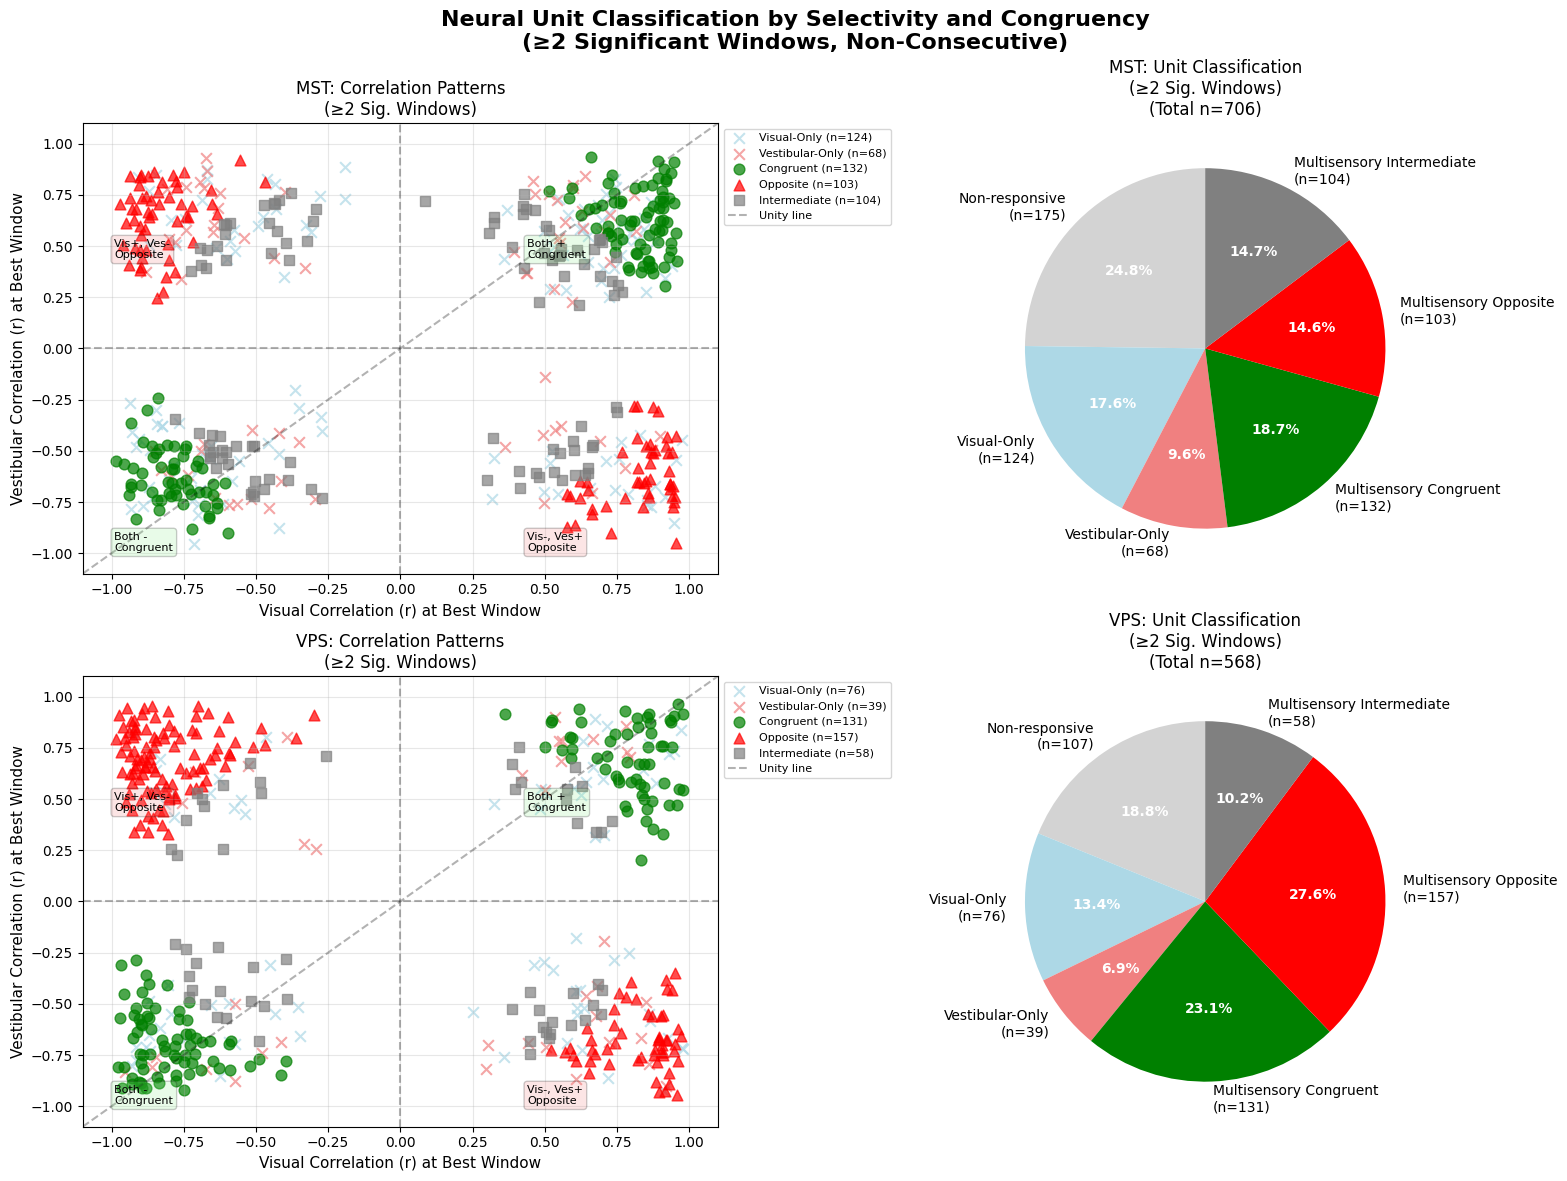


CREATING FIGURE 3: TEMPORAL EVOLUTION
Figure 3 saved as 'figure3_congruency_temporal_min2windows.png'


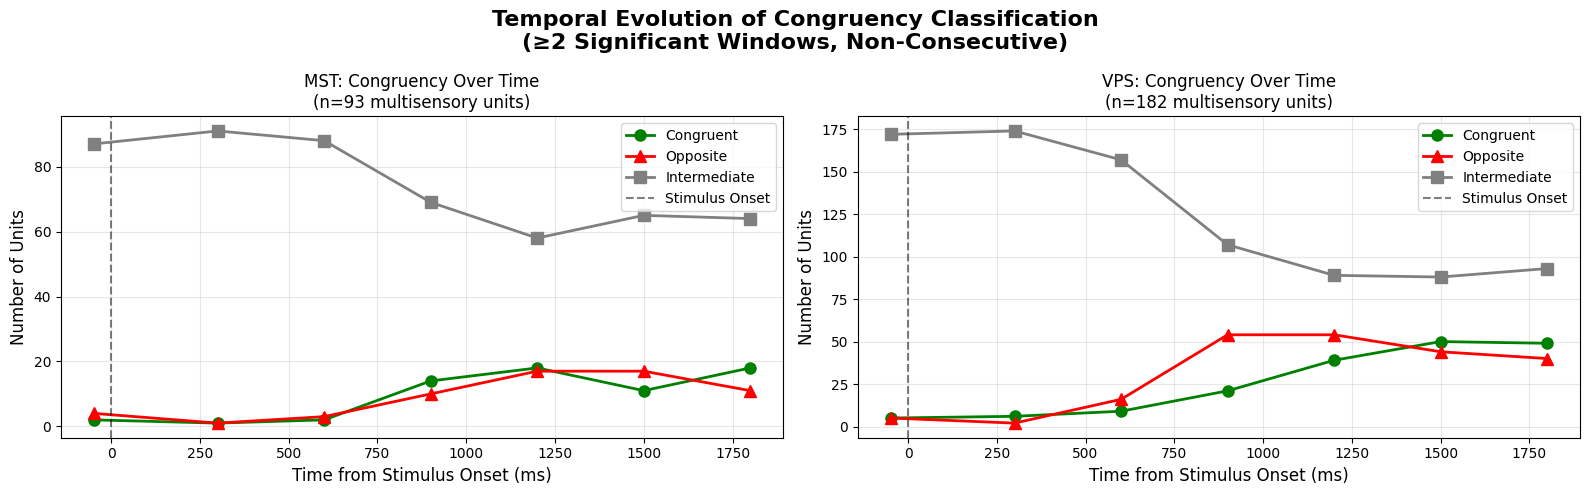


FINAL STATISTICS (≥2 SIGNIFICANT WINDOWS, NON-CONSECUTIVE)

Simple Categorization:
  Non-responsive      :  440 ( 32.5%)
  Visual-Only         :  461 ( 34.1%)
  Vestibular-Only     :  177 ( 13.1%)
  Combined            :  275 ( 20.3%)

Congruency Classification (Fisher's method):
  Non-responsive                :  326 ( 24.1%)
  Visual-Only                   :  207 ( 15.3%)
  Vestibular-Only               :  117 (  8.6%)
  Multisensory Congruent        :  267 ( 19.7%)
  Multisensory Opposite         :  264 ( 19.5%)
  Multisensory Intermediate     :  172 ( 12.7%)

BREAKDOWN BY AREA

MST (n=706):
----------------------------------------
  Non-responsive      :  252 ( 35.7%)
  Visual-Only         :  263 ( 37.3%)
  Vestibular-Only     :   98 ( 13.9%)
  Combined            :   93 ( 13.2%)

VPS (n=568):
----------------------------------------
  Non-responsive      :  138 ( 24.3%)
  Visual-Only         :  181 ( 31.9%)
  Vestibular-Only     :   67 ( 11.8%)
  Combined            :  182 ( 32.0

In [151]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import chi2
import seaborn as sns
import ast
import json
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# PART 1: DATA LOADING & PREPROCESSING
# ============================================================================

def parse_list_column(value):
    """Parse string representation of list to actual list"""
    if isinstance(value, list):
        return value
    if isinstance(value, np.ndarray):
        return value.tolist()
    if value is None:
        return []
    try:
        if pd.isna(value):
            return []
    except (ValueError, TypeError):
        pass
    if isinstance(value, str):
        try:
            return ast.literal_eval(value)
        except:
            try:
                return json.loads(value)
            except:
                return []
    return []

def extract_value_at_best_window(row, metric_prefix, modality):
    """Extract metric value at best center time for given modality"""
    try:
        best_center = row[f'{metric_prefix}_{modality}_best_center_ms']
        if pd.isna(best_center):
            return np.nan
        
        centers = parse_list_column(row[f'{metric_prefix}_{modality}_centers'])
        values = parse_list_column(row[f'{metric_prefix}_{modality}_r' if metric_prefix == 'correlation' else 
                                       f'{metric_prefix}_{modality}_thresholds' if metric_prefix == 'neurometric' else
                                       f'{metric_prefix}_{modality}_F'])
        
        if len(centers) == 0 or len(values) == 0:
            return np.nan
        
        centers_array = np.array(centers)
        idx = np.argmin(np.abs(centers_array - best_center))
        
        return values[idx] if idx < len(values) else np.nan
    except:
        return np.nan

def is_selective(row, modality, alpha=0.05, min_windows=2):
    """
    Check if unit is selective for given modality
    
    NEW CRITERION: Requires significance in at least min_windows time windows
    (do NOT need to be consecutive) to reduce false positives from multiple comparisons
    
    Parameters:
    -----------
    row : pd.Series
        Row from dataframe
    modality : str
        'vis', 'ves', or 'comb'
    alpha : float
        Significance threshold (default 0.05)
    min_windows : int
        Minimum number of significant windows required (default 2)
        Does NOT need to be consecutive
    
    Returns:
    --------
    bool : True if unit has ≥ min_windows significant windows
    
    Rationale:
    ----------
    With ~20 time windows and alpha=0.05, we expect ~1 false positive by chance.
    Requiring ≥2 significant windows reduces false positive rate to ~26%.
    This is more conservative than "any 1 window" but less strict than 
    requiring consecutive windows (which might miss transient responses).
    """
    try:
        p_values = parse_list_column(row[f'anova_{modality}_p'])
        if len(p_values) == 0:
            return False
        
        # Count how many windows are significant (anywhere in the list)
        n_significant = sum(not np.isnan(p) and p < alpha for p in p_values)
        
        return n_significant >= min_windows
    except:
        return False

def categorize_simple(row):
    """
    Categorize unit based on selectivity with ≥2 significant windows criterion
    
    Multisensory = (vis_selective AND ves_selective) OR comb_selective
    where each modality must be significant in ≥2 windows (non-consecutive)
    """
    if (row['vis_selective'] and row['ves_selective']):
        return 'Combined'
    elif row['vis_selective']:
        return 'Visual-Only'
    elif row['ves_selective']:
        return 'Vestibular-Only'
    else:
        return 'Non-responsive'

def classify_congruency(row):
    """
    Classify congruency using Fisher's method on best-window correlations.
    
    MULTISENSORY DEFINITION:
    A unit is "Multisensory" if:
      - (vis_selective AND ves_selective) OR comb_selective
    
    Where selectivity requires ≥2 significant windows (non-consecutive)
    """
    threshold = 0.05
    
    # Check if unit is selective for visual and/or vestibular
    vis_selective = row['vis_selective']
    ves_selective = row['ves_selective']
    comb_selective = row['comb_selective']
    
    # Multisensory definition
    is_multisensory = (vis_selective and ves_selective) or comb_selective
    
    if not vis_selective and not ves_selective and not comb_selective:
        return 'Non-responsive'
    
    if vis_selective and not ves_selective and not comb_selective:
        return 'Visual-Only'
    
    if ves_selective and not vis_selective and not comb_selective:
        return 'Vestibular-Only'
    
    # For multisensory units, check congruency
    if is_multisensory:
        vis_corr_r = row['vis_corr_r_best']
        ves_corr_r = row['ves_corr_r_best']
        vis_corr_p = row['vis_corr_p_best']
        ves_corr_p = row['ves_corr_p_best']
        
        # Check if both correlations exist and are valid
        if (pd.notna(vis_corr_p) and pd.notna(ves_corr_p) and 
            pd.notna(vis_corr_r) and pd.notna(ves_corr_r) and
            vis_corr_p > 0 and ves_corr_p > 0):
            
            # Fisher's method: -2 * ln(p1 * p2) follows chi-square with 4 df
            fisher_stat = -2 * (np.log(vis_corr_p) + np.log(ves_corr_p))
            combined_p = 1 - chi2.cdf(fisher_stat, df=4)
            
            # If combined significance is < 0.05
            if combined_p < 0.05:
                vis_positive = vis_corr_r > 0
                ves_positive = ves_corr_r > 0
                
                if vis_positive == ves_positive:
                    return 'Multisensory Congruent'
                else:
                    return 'Multisensory Opposite'
            else:
                return 'Multisensory Intermediate'
        else:
            return 'Multisensory Intermediate'
    
    return 'Other'

# ============================================================================
# LOAD AND PROCESS DATA
# ============================================================================

# Load the data
df = pd.read_csv(r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMPtuning_neuralfeatures\zarya_pooled_neural_features_tuning_stimOn.csv')

print("\n" + "="*80)
print("LOADING AND PREPROCESSING DATA")
print("="*80)
print(f"\nTotal units loaded: {len(df)}")

# Parse all list columns
list_columns = [col for col in df.columns if any(x in col for x in ['centers', 'thresholds', 'r2', 'mu', 'sigma', '_F', '_p', '_r'])]
for col in list_columns:
    if col.endswith('_best_center_ms') or col == 'overall_firing_rate':
        continue
    df[col] = df[col].apply(parse_list_column)

# Extract best-window values for correlations
print("Extracting best-window correlation values...")
df['vis_corr_r_best'] = df.apply(lambda row: extract_value_at_best_window(row, 'correlation', 'vis'), axis=1)
df['ves_corr_r_best'] = df.apply(lambda row: extract_value_at_best_window(row, 'correlation', 'ves'), axis=1)

# Extract p-values at best windows
def extract_p_at_best_window(row, modality):
    try:
        best_center = row[f'correlation_{modality}_best_center_ms']
        if pd.isna(best_center):
            return np.nan
        centers = row[f'correlation_{modality}_centers']
        p_values = row[f'correlation_{modality}_p']
        if len(centers) == 0 or len(p_values) == 0:
            return np.nan
        centers_array = np.array(centers)
        idx = np.argmin(np.abs(centers_array - best_center))
        return p_values[idx] if idx < len(p_values) else np.nan
    except:
        return np.nan

df['vis_corr_p_best'] = df.apply(lambda row: extract_p_at_best_window(row, 'vis'), axis=1)
df['ves_corr_p_best'] = df.apply(lambda row: extract_p_at_best_window(row, 'ves'), axis=1)

# Apply selectivity criteria with ≥2 SIGNIFICANT WINDOWS REQUIREMENT (non-consecutive)
print("\n" + "="*80)
print("APPLYING SELECTIVITY CRITERIA")
print("="*80)
print("NEW CRITERION: Requires ≥2 significant windows (p < 0.05)")
print("Windows do NOT need to be consecutive")
print("Rationale: Reduces false positives from multiple comparisons")
print("           while still capturing transient responses")
print("="*80)

df['ves_selective'] = df.apply(lambda row: is_selective(row, 'ves', alpha=0.05, min_windows=1), axis=1)
df['vis_selective'] = df.apply(lambda row: is_selective(row, 'vis', alpha=0.05, min_windows=1), axis=1)
df['comb_selective'] = df.apply(lambda row: is_selective(row, 'comb', alpha=0.05, min_windows=1), axis=1)

# Print selectivity statistics
print(f"\nSelectivity Results (≥2 significant windows, non-consecutive):")
print(f"  Visual selective:      {df['vis_selective'].sum():4d} / {len(df)} ({100*df['vis_selective'].sum()/len(df):.1f}%)")
print(f"  Vestibular selective:  {df['ves_selective'].sum():4d} / {len(df)} ({100*df['ves_selective'].sum()/len(df):.1f}%)")
print(f"  Combined selective:    {df['comb_selective'].sum():4d} / {len(df)} ({100*df['comb_selective'].sum()/len(df):.1f}%)")
print(f"  Both vis AND ves:      {(df['vis_selective'] & df['ves_selective']).sum():4d} / {len(df)} ({100*(df['vis_selective'] & df['ves_selective']).sum()/len(df):.1f}%)")

# Apply simple categorization
df['unit_category_simple'] = df.apply(categorize_simple, axis=1)

# Apply congruency classification
print("\nApplying congruency classification...")
df['unit_category_congruency'] = df.apply(classify_congruency, axis=1)

# Calculate SCI for analysis
df['SCI'] = df['vis_corr_r_best'] * df['ves_corr_r_best']

print(f"\nPreprocessing complete!")
print(f"\nSimple categories found:")
for cat, count in df['unit_category_simple'].value_counts().items():
    print(f"  {cat:20s}: {count:4d} ({100*count/len(df):5.1f}%)")
print(f"\nCongruency categories found:")
for cat, count in df['unit_category_congruency'].value_counts().items():
    print(f"  {cat:30s}: {count:4d} ({100*count/len(df):5.1f}%)")

# ============================================================================
# FIGURE 1: STATIC ANALYSIS (2x2 SCATTER + PIE)
# ============================================================================

category_colors = {
    'Non-responsive': 'lightgray',
    'Visual-Only': 'lightblue', 
    'Vestibular-Only': 'lightcoral',
    'Combined': 'orange',
    'Multisensory Congruent': 'green',
    'Multisensory Opposite': 'red',
    'Multisensory Intermediate': 'gray',
    'Other': 'darkgray'
}

print("\n" + "="*80)
print("CREATING FIGURE 1: STATIC ANALYSIS")
print("="*80)

fig1, axes = plt.subplots(2, 2, figsize=(16, 12))
fig1.suptitle('Neural Unit Classification by Selectivity and Congruency\n(≥2 Significant Windows, Non-Consecutive)', 
             fontsize=16, fontweight='bold')

areas = ['MST', 'VPS']

for i, area in enumerate(areas):
    area_data = df[df['area'] == area]
    
    # SUBPLOT 1: Scatter plot
    ax1 = axes[i, 0]
    
    corr_data = area_data.dropna(subset=['vis_corr_r_best', 'ves_corr_r_best'])
    
    if len(corr_data) > 0:
        plot_categories = [
            'Visual-Only', 'Vestibular-Only', 
            'Multisensory Congruent', 'Multisensory Opposite', 'Multisensory Intermediate'
        ]
        
        for category in plot_categories:
            cat_data = corr_data[corr_data['unit_category_congruency'] == category]
            if len(cat_data) > 0:
                if category == 'Visual-Only':
                    marker = 'x'
                elif category == 'Vestibular-Only':
                    marker = 'x'
                elif 'Congruent' in category:
                    marker = 'o'
                elif 'Opposite' in category:
                    marker = '^'
                else:
                    marker = 's'
                
                ax1.scatter(cat_data['vis_corr_r_best'], cat_data['ves_corr_r_best'], 
                           alpha=0.7, s=60, color=category_colors[category], 
                           marker=marker, label=f'{category.replace("Multisensory ", "")} (n={len(cat_data)})')
        
        ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
        ax1.axvline(x=0, color='k', linestyle='--', alpha=0.3)
        ax1.set_xlim([-1.1, 1.1])
        ax1.set_ylim([-1.1, 1.1])
        ax1.plot([-1.1, 1.1], [-1.1, 1.1], 'k--', alpha=0.3, label='Unity line')
        
        ax1.set_xlabel('Visual Correlation (r) at Best Window', fontsize=11)
        ax1.set_ylabel('Vestibular Correlation (r) at Best Window', fontsize=11)
        ax1.set_title(f'{area}: Correlation Patterns\n(≥2 Sig. Windows)')
        ax1.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))
        ax1.grid(True, alpha=0.3)
        
        # Quadrant Labels
        ax1.text(0.7, 0.7, 'Both +\nCongruent', transform=ax1.transAxes, 
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.2), fontsize=8)
        ax1.text(0.05, 0.7, 'Vis+, Ves-\nOpposite', transform=ax1.transAxes,
                bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.2), fontsize=8)
        ax1.text(0.7, 0.05, 'Vis-, Ves+\nOpposite', transform=ax1.transAxes,
                bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.2), fontsize=8)
        ax1.text(0.05, 0.05, 'Both -\nCongruent', transform=ax1.transAxes,
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.2), fontsize=8)
    else:
        ax1.text(0.5, 0.5, 'No correlation data available', ha='center', va='center', transform=ax1.transAxes)
        ax1.set_title(f'{area}: Correlation Patterns')
    
    # SUBPLOT 2: Pie chart
    ax2 = axes[i, 1]
    
    category_counts = area_data['unit_category_congruency'].value_counts()
    
    all_categories = ['Non-responsive', 'Visual-Only', 'Vestibular-Only', 
                     'Multisensory Congruent', 'Multisensory Opposite', 'Multisensory Intermediate']
    
    counts = []
    labels = []
    colors = []
    
    for cat in all_categories:
        count = category_counts.get(cat, 0)
        if count > 0:
            counts.append(count)
            labels.append(f'{cat}\n(n={count})')
            colors.append(category_colors[cat])
    
    if len(counts) > 0:
        wedges, texts, autotexts = ax2.pie(counts, labels=labels, colors=colors, autopct='%1.1f%%',
                                          startangle=90, textprops={'fontsize': 10})
        
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontweight('bold')
    
    ax2.set_title(f'{area}: Unit Classification\n(≥2 Sig. Windows)\n(Total n={len(area_data)})')

plt.tight_layout()
plt.savefig('figure1_static_analysis_min2windows.png', dpi=300, bbox_inches='tight')
print("Figure 1 saved as 'figure1_static_analysis_min2windows.png'")
plt.show()

# ============================================================================
# FIGURE 3 LOWER PANEL: CONGRUENCY COUNTS OVER TIME
# ============================================================================

print("\n" + "="*80)
print("CREATING FIGURE 3: TEMPORAL EVOLUTION")
print("="*80)

fig3, axes = plt.subplots(1, 2, figsize=(16, 5))
fig3.suptitle('Temporal Evolution of Congruency Classification\n(≥2 Significant Windows, Non-Consecutive)', 
             fontsize=16, fontweight='bold')

def classify_congruency_at_window(row, window_idx):
    """Classify congruency at specific time window"""
    try:
        vis_corr_r_list = row['correlation_vis_r']
        ves_corr_r_list = row['correlation_ves_r']
        vis_corr_p_list = row['correlation_vis_p']
        ves_corr_p_list = row['correlation_ves_p']
        
        if (len(vis_corr_r_list) <= window_idx or len(ves_corr_r_list) <= window_idx or
            len(vis_corr_p_list) <= window_idx or len(ves_corr_p_list) <= window_idx):
            return 'Insufficient Data'
        
        vis_corr_r = vis_corr_r_list[window_idx]
        ves_corr_r = ves_corr_r_list[window_idx]
        vis_corr_p = vis_corr_p_list[window_idx]
        ves_corr_p = ves_corr_p_list[window_idx]
        
        if (pd.notna(vis_corr_p) and pd.notna(ves_corr_p) and 
            pd.notna(vis_corr_r) and pd.notna(ves_corr_r) and
            vis_corr_p > 0 and ves_corr_p > 0):
            
            fisher_stat = -2 * (np.log(vis_corr_p) + np.log(ves_corr_p))
            combined_p = 1 - chi2.cdf(fisher_stat, df=4)
            
            if combined_p < 0.05:
                vis_positive = vis_corr_r > 0
                ves_positive = ves_corr_r > 0
                
                if vis_positive == ves_positive:
                    return 'Congruent'
                else:
                    return 'Opposite'
            else:
                return 'Intermediate'
        else:
            return 'Insufficient Data'
    except:
        return 'Insufficient Data'

for col_idx, area in enumerate(areas):
    area_data = df[df['area'] == area]
    multisensory_data = area_data[area_data['unit_category_simple'] == 'Combined']
    
    if len(multisensory_data) == 0:
        axes[col_idx].text(0.5, 0.5, f'No multisensory units in {area}', 
                          ha='center', va='center', transform=axes[col_idx].transAxes)
        continue
    
    sample_row = multisensory_data.iloc[0]
    time_windows = sample_row['correlation_vis_centers']
    
    if len(time_windows) == 0:
        continue
    
    ax = axes[col_idx]
    
    congruent_counts = []
    opposite_counts = []
    intermediate_counts = []
    
    for window_idx in range(len(time_windows)):
        congruent_count = 0
        opposite_count = 0
        intermediate_count = 0
        
        for idx, row in multisensory_data.iterrows():
            classification = classify_congruency_at_window(row, window_idx)
            if classification == 'Congruent':
                congruent_count += 1
            elif classification == 'Opposite':
                opposite_count += 1
            elif classification == 'Intermediate':
                intermediate_count += 1
        
        congruent_counts.append(congruent_count)
        opposite_counts.append(opposite_count)
        intermediate_counts.append(intermediate_count)
    
    ax.plot(time_windows, congruent_counts, color=category_colors['Multisensory Congruent'], 
            marker='o', linewidth=2, markersize=8, label='Congruent')
    ax.plot(time_windows, opposite_counts, color=category_colors['Multisensory Opposite'], 
            marker='^', linewidth=2, markersize=8, label='Opposite')
    ax.plot(time_windows, intermediate_counts, color=category_colors['Multisensory Intermediate'], 
            marker='s', linewidth=2, markersize=8, label='Intermediate')
    
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.5, linewidth=1.5, label='Stimulus Onset')
    ax.set_xlabel('Time from Stimulus Onset (ms)', fontsize=12)
    ax.set_ylabel('Number of Units', fontsize=12)
    ax.set_title(f'{area}: Congruency Over Time\n(n={len(multisensory_data)} multisensory units)', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('figure3_congruency_temporal_min2windows.png', dpi=300, bbox_inches='tight')
print("Figure 3 saved as 'figure3_congruency_temporal_min2windows.png'")
plt.show()

# ============================================================================
# STATISTICS
# ============================================================================

print("\n" + "="*80)
print("FINAL STATISTICS (≥2 SIGNIFICANT WINDOWS, NON-CONSECUTIVE)")
print("="*80)

print("\nSimple Categorization:")
for cat in ['Non-responsive', 'Visual-Only', 'Vestibular-Only', 'Combined']:
    count = len(df[df['unit_category_simple'] == cat])
    pct = 100 * count / len(df)
    print(f"  {cat:20s}: {count:4d} ({pct:5.1f}%)")

print("\nCongruency Classification (Fisher's method):")
for cat in ['Non-responsive', 'Visual-Only', 'Vestibular-Only', 
            'Multisensory Congruent', 'Multisensory Opposite', 'Multisensory Intermediate']:
    count = len(df[df['unit_category_congruency'] == cat])
    pct = 100 * count / len(df)
    print(f"  {cat:30s}: {count:4d} ({pct:5.1f}%)")

# Additional breakdown by area
print("\n" + "="*80)
print("BREAKDOWN BY AREA")
print("="*80)

for area in areas:
    area_data = df[df['area'] == area]
    print(f"\n{area} (n={len(area_data)}):")
    print("-" * 40)
    
    for cat in ['Non-responsive', 'Visual-Only', 'Vestibular-Only', 'Combined']:
        count = len(area_data[area_data['unit_category_simple'] == cat])
        pct = 100 * count / len(area_data) if len(area_data) > 0 else 0
        print(f"  {cat:20s}: {count:4d} ({pct:5.1f}%)")

print("\n" + "="*80)
print("Analysis complete!")
print("="*80)